# Explorative Analyse des NF-UNSW-NB15-v3 Datensatzes

Das Ziel dieses Notebooks ist es, ein grundlegendes Verständnis für den NF-UNSW-NB15-v3 Datensatz zu entwickeln. Wir werden die Daten laden, ihre Struktur untersuchen, die Verteilung der Zielvariable und der Features analysieren und Korrelationen aufdecken.



# Installation und Import der benötigten Pakete 


In [1]:
%pip install -r "./requirements.txt"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 12.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 12.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 8.8 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 8.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.1/808.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [transformers] [transformers]ub]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# 📚 Import Libraries und Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visualization Setup
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', 20)

print("🚀 Setup completed!")
print(f"📊 Pandas: {pd.__version__} | NumPy: {np.__version__}")

🚀 Setup completed!
📊 Pandas: 2.2.2 | NumPy: 1.26.4


# 📁 Dataset Loading

Bevor das Dataset geladen werden kann, muss es zuerst unter folgendem Link heruntergeladen werden:
https://rdm.uq.edu.au/files/abd2f5d8-e268-4ff0-84fb-f2f7b3ca3e8f 

Entpacken Sie den Ordner und legen sie die Bitte legen sie die `NF-UNSW-NB15-v3.csv`im Ordner ../data ab.


In [60]:
# 📁 Dataset Loading
# WICHTIG: Pfad zum NF-UNSW-NB15-v3.csv anpassen!
data_path = "../data/NF-UNSW-NB15-v3.csv" 

try:
    print("📥 Lade NF-UNSW-NB15-v3 Dataset...")
    df = pd.read_csv(data_path)
    print(f"✅ Dataset erfolgreich geladen!")
    print(f"📊 Shape: {df.shape}")
    print(f"💾 Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
except FileNotFoundError:
    print("❌ Dataset nicht gefunden!")
    

# Initial Assessment
print("\n📋 Dataset Overview:")
print(f"Samples: {len(df):,}")
print(f"Features: {df.shape[1]}")
print(f"Dtypes: {df.dtypes.value_counts().to_dict()}")

print("\n🔍 First 5 rows:")
pd.set_option('display.max_columns', None)
display(df.head())

print("\n📊 Missing values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    display(missing[missing > 0])
else:
    print("✅ No missing values")

📥 Lade NF-UNSW-NB15-v3 Dataset...
✅ Dataset erfolgreich geladen!
📊 Shape: (2365424, 55)
💾 Memory: 1390.30 MB

📋 Dataset Overview:
Samples: 2,365,424
Features: 55
Dtypes: {dtype('int64'): 49, dtype('O'): 3, dtype('float64'): 3}

🔍 First 5 rows:


,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,5.0,146,2,178,2,0,0,0,2,0,0,31,31,89,73,73,89,89.000000,73.000000,0,0,0,0,389333,474666,4,0,0,0,0,0,0,0,0,46779,1,60,0,0,0,0,0,0,0,0,0,0,Benign
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,11.0,4704,28,2976,28,27,27,27,335,334,334,31,32,984,52,52,984,8.883582,14.041791,1988,7,1068,6,112000,70857,34,18,2,2,0,14480,14480,50176,196,0,0,0,0,0,91,12,19,0,90,12,19,0,Benign
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,37.0,13662,238,548216,438,27,27,27,2460,2459,2459,31,32,1500,52,52,1500,222.852033,5.553659,1735,21,272908,196,44411,1782091,288,0,4,32,352,65160,34752,50944,199,0,0,0,0,0,1843,10,119,0,1843,5,88,0,Benign
3,1424242193145,1424242193146,59.166.0.8,43310,149.171.126.7,53,17,5.0,146,2,178,2,0,0,0,1,0,0,31,31,89,73,73,89,178.000000,146.000000,0,0,0,0,584000,712000,4,0,0,0,0,0,0,0,0,3211,1,60,0,0,0,0,0,0,0,0,0,0,Benign
4,1424242193239,1424242193241,59.166.0.1,45870,149.171.126.1,53,17,5.0,130,2,162,2,0,0,0,1,0,0,31,31,81,65,65,81,162.000000,130.000000,0,0,0,0,520000,648000,4,0,0,0,0,0,0,0,0,5771,1,60,0,0,0,0,0,0,0,0,0,0,Benign



📊 Missing values:


SRC_TO_DST_SECOND_BYTES    63425
dtype: int64


# Basis-Analyse: Dimension, Datentypen und fehlende Werte
Was wird gemacht? Wir verschaffen uns einen ersten Überblick über die grundlegenden Eigenschaften des Datensatzes:

1. Form und Größe: Wie viele Zeilen und Spalten gibt es?
2. Datentypen: Welche Spalten sind numerisch, welche kategorial (object)?
3. Fehlende Werte: Gibt es Spalten mit unvollständigen Daten?

In [61]:
# Umfassende Informationen zu Spalten, Datentypen und Nicht-Null-Werten
print("--- Informationen zum DataFrame ---")
df.info(verbose=True, show_counts=True)

print("\nDeskriptive Statistiken für numerische Spalten:")
display(df.describe().transpose())
print("\nDeskriptive Statistiken für kategoriale Spalten:")
display(df.describe(include='object').transpose())

--- Informationen zum DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2365424 entries, 0 to 2365423
Data columns (total 55 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   FLOW_START_MILLISECONDS      2365424 non-null  int64  
 1   FLOW_END_MILLISECONDS        2365424 non-null  int64  
 2   IPV4_SRC_ADDR                2365424 non-null  object 
 3   L4_SRC_PORT                  2365424 non-null  int64  
 4   IPV4_DST_ADDR                2365424 non-null  object 
 5   L4_DST_PORT                  2365424 non-null  int64  
 6   PROTOCOL                     2365424 non-null  int64  
 7   L7_PROTO                     2365424 non-null  float64
 8   IN_BYTES                     2365424 non-null  int64  
 9   IN_PKTS                      2365424 non-null  int64  
 10  OUT_BYTES                    2365424 non-null  int64  
 11  OUT_PKTS                     2365424 non-null  int64  
 12  TCP_FL

,count,mean,std,min,25%,50%,75%,max
FLOW_START_MILLISECONDS,2365424.0,1.423141e+12,1.144853e+09,1.421927e+12,1.421951e+12,1.424221e+12,1.424242e+12,1.424263e+12
FLOW_END_MILLISECONDS,2365424.0,1.423141e+12,1.144853e+09,1.421927e+12,1.421951e+12,1.424221e+12,1.424242e+12,1.424263e+12
L4_SRC_PORT,2365424.0,3.266052e+04,1.915897e+04,0.000000e+00,1.592700e+04,3.281500e+04,4.910000e+04,6.553500e+04
L4_DST_PORT,2365424.0,1.114841e+04,1.839424e+04,0.000000e+00,2.500000e+01,8.000000e+01,1.462925e+04,6.553500e+04
PROTOCOL,2365424.0,8.730817e+00,6.384764e+00,0.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,2.550000e+02
L7_PROTO,2365424.0,2.353191e+01,2.126820e+01,0.000000e+00,5.000000e+00,3.600000e+01,3.700000e+01,4.210000e+02
IN_BYTES,2365424.0,4.413591e+03,6.769945e+04,1.000000e+00,4.810000e+02,1.580000e+03,3.048000e+03,2.702093e+07
IN_PKTS,2365424.0,3.528169e+01,7.839349e+01,1.000000e+00,4.000000e+00,1.600000e+01,4.400000e+01,2.016600e+04
OUT_BYTES,2365424.0,3.432003e+04,1.550732e+05,0.000000e+00,3.120000e+02,2.456000e+03,1.437000e+04,1.465675e+07
OUT_PKTS,2365424.0,4.471138e+01,1.163444e+02,0.000000e+00,4.000000e+00,1.800000e+01,4.200000e+01,1.102400e+04



Deskriptive Statistiken für kategoriale Spalten:


,count,unique,top,freq
IPV4_SRC_ADDR,2365424,40,59.166.0.2,225316
IPV4_DST_ADDR,2365424,40,149.171.126.4,224702
Attack,2365424,10,Benign,2237731


# Strukturanalyse: Features klassifizieren
Basierend auf der info()-Ausgabe und dem Wissen über den Datensatz werden die Spalten systematisch in Zielvariablen, kategoriale Features und numerische Features eingeteilt. Diese Listen sind die Grundlage für alle weiteren Analysen.

In [62]:
target_columns = ['Label', 'Attack']
categorical_columns = ['IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO','FTP_COMMAND_RET_CODE', 'DNS_QUERY_TYPE', 'ICMP_IPV4_TYPE', 'ICMP_TYPE', 'SERVER_TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'TCP_FLAGS']
all_columns = df.columns.tolist()
numeric_columns = [col for col in all_columns if col not in target_columns + categorical_columns]
final_feature_columns = [col for col in df.columns 
                        if col not in target_columns]
print(f"Anzahl numerischer Features: {len(numeric_columns)}")
print(f"Anzahl kategorialer Features: {len(categorical_columns)}")
print(f"Anzahl Zielvariablen: {len(target_columns)}")

Anzahl numerischer Features: 40
Anzahl kategorialer Features: 13
Anzahl Zielvariablen: 2


# Datenqualität: Analyse von NaN- und inf-Werten
Wir quantifizieren das Problem der fehlenden und unendlichen Werte.

In [63]:
# Zähle NaN-Werte pro Spalte
missing_values = df.isnull().sum()
print("Spalten mit fehlenden Werten (NaN):")
print(missing_values[missing_values > 0])

# Zähle unendliche Werte pro Spalte
inf_values = df.isin([np.inf, -np.inf]).sum()
print("\nSpalten mit unendlichen Werten (inf):")
print(inf_values[inf_values > 0])

Spalten mit fehlenden Werten (NaN):
SRC_TO_DST_SECOND_BYTES    63425
dtype: int64

Spalten mit unendlichen Werten (inf):
SRC_TO_DST_SECOND_BYTES     59068
DST_TO_SRC_SECOND_BYTES    122493
dtype: int64


In [ ]:
import pandas as pd
import numpy as np

def analyze_nan_inf_attacks(df: pd.DataFrame) -> pd.Series:
    """
    Analysiert ein DataFrame auf Zeilen mit NaN- oder unendlichen Werten.

    Zählt die Vorkommen jeder 'Attack'-Kategorie in Zeilen, die entweder
    np.nan (in beliebigen Spalten) oder np.inf (in numerischen Spalten) enthalten.

    Parameters
    ----------
    df : pd.DataFrame
        Das Eingabe-DataFrame. Es wird erwartet, dass eine Spalte
        namens 'Attack' existiert.

    Returns
    -------
    pd.Series
        Zählung der Angriffsklassen (Value Counts) der gefilterten Zeilen.

    See Also
    --------
    pandas.DataFrame.isnull : Prüft auf fehlende Werte.
    numpy.isinf : Prüft auf Unendlichkeit.
    """
    # Erstellen einer Maske für Zeilen mit NaN- oder inf-Werten
    mask_nan_inf = df.select_dtypes(include=[np.number]).apply(lambda x: np.isinf(x)).any(axis=1) | df.isnull().any(axis=1)
    
    # Filtern des DataFrames, um nur die Zeilen mit Problemen zu erhalten
    problematic_samples = df[mask_nan_inf]
    
    # Zählen der Angriffskategorien in den problematischen Samples
    attack_counts = problematic_samples['Attack'].value_counts()
    
    return attack_counts

df_copy = df.copy()
print("Analyse der Angriffsklassen für Samples mit NaN- oder inf-Werten:")
problematic_attack_counts = analyze_nan_inf_attacks(df_copy)
print(problematic_attack_counts)

Analyse der Angriffsklassen für Samples mit NaN- oder inf-Werten:
Attack
Benign            86704
Generic           14891
Fuzzers            8228
Reconnaissance     5783
Exploits           3932
Backdoor           1208
DoS                 930
Shellcode           795
Worms                22
Name: count, dtype: int64


In [65]:
import pandas as pd
import numpy as np

def find_nan_or_inf_samples(df: pd.DataFrame) -> pd.DataFrame:
    """
    Findet alle Zeilen in einem DataFrame, die mindestens einen NaN- oder 
    unendlichen Wert enthalten, und gibt sie als neues DataFrame zurück.

    Args:
        df: Das zu analysierende pandas DataFrame.

    Returns:
        Ein neues pandas DataFrame, das nur die Zeilen mit NaN- oder 
        unendlichen Werten enthält.
    """
    # Maske für NaN-Werte erstellen
    nan_mask = df.isnull().any(axis=1)
    
    # Maske für unendliche Werte in numerischen Spalten erstellen
    inf_mask = pd.Series([False] * len(df), index=df.index)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if not numeric_cols.empty:
        inf_mask = df[numeric_cols].isin([np.inf, -np.inf]).any(axis=1)

    # Kombinierte Maske
    combined_mask = nan_mask | inf_mask
    
    # DataFrame mit den problematischen Zeilen zurückgeben
    return df[combined_mask]

# --- Beispiel für die Anwendung der Funktion ---
problematic_df = find_nan_or_inf_samples(df)

print(f"Insgesamt {len(problematic_df)} Samples mit NaN- oder inf-Werten gefunden.")
print("Hier sind die ersten 5 problematischen Samples:")
problematische_spalten = [
    'SRC_TO_DST_SECOND_BYTES',
    'DST_TO_SRC_SECOND_BYTES',
    'IN_BYTES',
    'OUT_BYTES',
    'FLOW_DURATION_MILLISECONDS',
    'FLOW_START_MILLISECONDS',
    'FLOW_END_MILLISECONDS'
]

# Erstellen Sie einen neuen DataFrame, der nur diese Spalten enthält
df_reduziert = problematic_df[problematische_spalten]
display(df_reduziert.head())

Insgesamt 122493 Samples mit NaN- oder inf-Werten gefunden.
Hier sind die ersten 5 problematischen Samples:


,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,IN_BYTES,OUT_BYTES,FLOW_DURATION_MILLISECONDS,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS
40,NaN,inf,1064,0,0,1424242194737,1424242194737
63,inf,inf,130,162,0,1424242195639,1424242195640
71,NaN,inf,104,0,0,1424242195905,1424242195905
81,inf,inf,130,162,0,1424242196341,1424242196342
97,inf,inf,130,162,0,1424242196992,1424242196993



- **Bestätigung der Datenprobleme:** Die Analyse quantifiziert die zuvor festgestellten Datenqualitätsprobleme. `SRC_TO_DST_SECOND_BYTES` weist sowohl eine große Anzahl von `NaN`-Werten (über 63.000) als auch `inf`-Werten (über 59.000) auf.
- **Unendliche Werte:** Auch `DST_TO_SRC_SECOND_BYTES` ist von über 122.000 unendlichen Werten betroffen. die weitere Analyse zeigt, dass solche Werte bei der Berechnung von Raten (Bytes/Sekunde) entstehen, wenn die Dauer des Flows Null ist. Die Dauer des Flows scheint bei diesen Flows so kleiner als 1 ms zu sein, wodurch auf 0 gerundet wird. Dies bestätigt teilweise der Vergleich von `FLOW_START_MILLISECONDS`und `FLOW_END_MILLISECONDS`
- **Handlungsbedarf:** Diese "schmutzigen" Daten müssen im Preprocessing-Notebook systematisch bereinigt werden, da sie die meisten Algorithmen zum Absturz bringen oder zu falschen Ergebnissen führen würden.
- **Vorgehen:** Der niedrigste Wert von `FLOW_DURATION_MILLISECONDS` sollte von 0 auf 1 geändert werden. Analog hierzu sollten die betroffenen Werte für `SRC_TO_DST_SECOND_BYTES` und `DST_TO_SRC_SECOND_BYTES` neu berechnet werden.

In [66]:
import numpy as np
import pandas as pd

def clean_flow_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Bereinigt einen DataFrame von Netzwerk-Flow-Daten, um Probleme mit
    unendlichen Werten und NaN-Werten zu beheben, die durch eine Flow-Dauer
    von Null entstehen.

    Diese Funktion identifiziert Zeilen, in denen 'FLOW_DURATION_MILLISECONDS'
    Null ist, und setzt diesen Wert auf 1, um eine Division durch Null zu
    vermeiden. Anschließend werden 'SRC_TO_DST_SECOND_BYTES' und
    'DST_TO_SRC_SECOND_BYTES' für die betroffenen Zeilen basierend auf der
    neuen Dauer neu berechnet.

    Zusätzlich werden alle verbleibenden NaN-Werte in den ratenbasierten
    Spalten mit 0 gefüllt.

    Returns:
        Der bereinigte DataFrame.
    """
    # Erstellen einer Kopie, um die ursprünglichen Daten nicht zu verändern
    df_cleaned = df.copy()

    # Maske für Zeilen, bei denen die Dauer 0 ist
    zero_duration_mask = df_cleaned['FLOW_DURATION_MILLISECONDS'] == 0

    # Setzen der Dauer auf 1 ms für diese Zeilen
    df_cleaned.loc[zero_duration_mask, 'FLOW_DURATION_MILLISECONDS'] = 1

    # Neuberechnung der Raten für die geänderten Zeilen
    new_duration_seconds = df_cleaned.loc[zero_duration_mask, 'FLOW_DURATION_MILLISECONDS']

    # Neuberechnung für SRC_TO_DST_SECOND_BYTES
    df_cleaned.loc[zero_duration_mask, 'SRC_TO_DST_SECOND_BYTES'] = \
        df_cleaned.loc[zero_duration_mask, 'OUT_BYTES'] / new_duration_seconds

    # Neuberechnung für DST_TO_SRC_SECOND_BYTES
    df_cleaned.loc[zero_duration_mask, 'DST_TO_SRC_SECOND_BYTES'] = \
        df_cleaned.loc[zero_duration_mask, 'IN_BYTES'] / new_duration_seconds


    print(f"{zero_duration_mask.sum()} Zeilen mit einer Dauer von 0 wurden auf 1 ms korrigiert und die Raten neu berechnet.")

    return df_cleaned

# Beispiel für die Anwendung:
df_for_corr = clean_flow_data(df)
problematic_df = find_nan_or_inf_samples(df_for_corr)
df_reduziert = problematic_df[problematische_spalten]
display(df_reduziert.head())


122493 Zeilen mit einer Dauer von 0 wurden auf 1 ms korrigiert und die Raten neu berechnet.


,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,IN_BYTES,OUT_BYTES,FLOW_DURATION_MILLISECONDS,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS


In [10]:
display(df[problematische_spalten].head())

,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,IN_BYTES,OUT_BYTES,FLOW_DURATION_MILLISECONDS,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS
0,89.000000,73.000000,146,178,2,1424242193040,1424242193043
1,8.883582,14.041791,4704,2976,335,1424242192744,1424242193079
2,222.852033,5.553659,13662,548216,2460,1424242190649,1424242193109
3,178.000000,146.000000,146,178,1,1424242193145,1424242193146
4,162.000000,130.000000,130,162,1,1424242193239,1424242193241


# Analyse der Zielvariable: Attack-Kategorien
Was wird gemacht? Das wichtigste Merkmal für unser späteres Modell ist die Zielvariable Attack. Wir visualisieren ihre Verteilung, um zu verstehen, wie häufig jede Angriffskategorie im Datensatz vorkommt. Dies ist entscheidend, um ein mögliches Klassenungleichgewicht zu identifizieren.

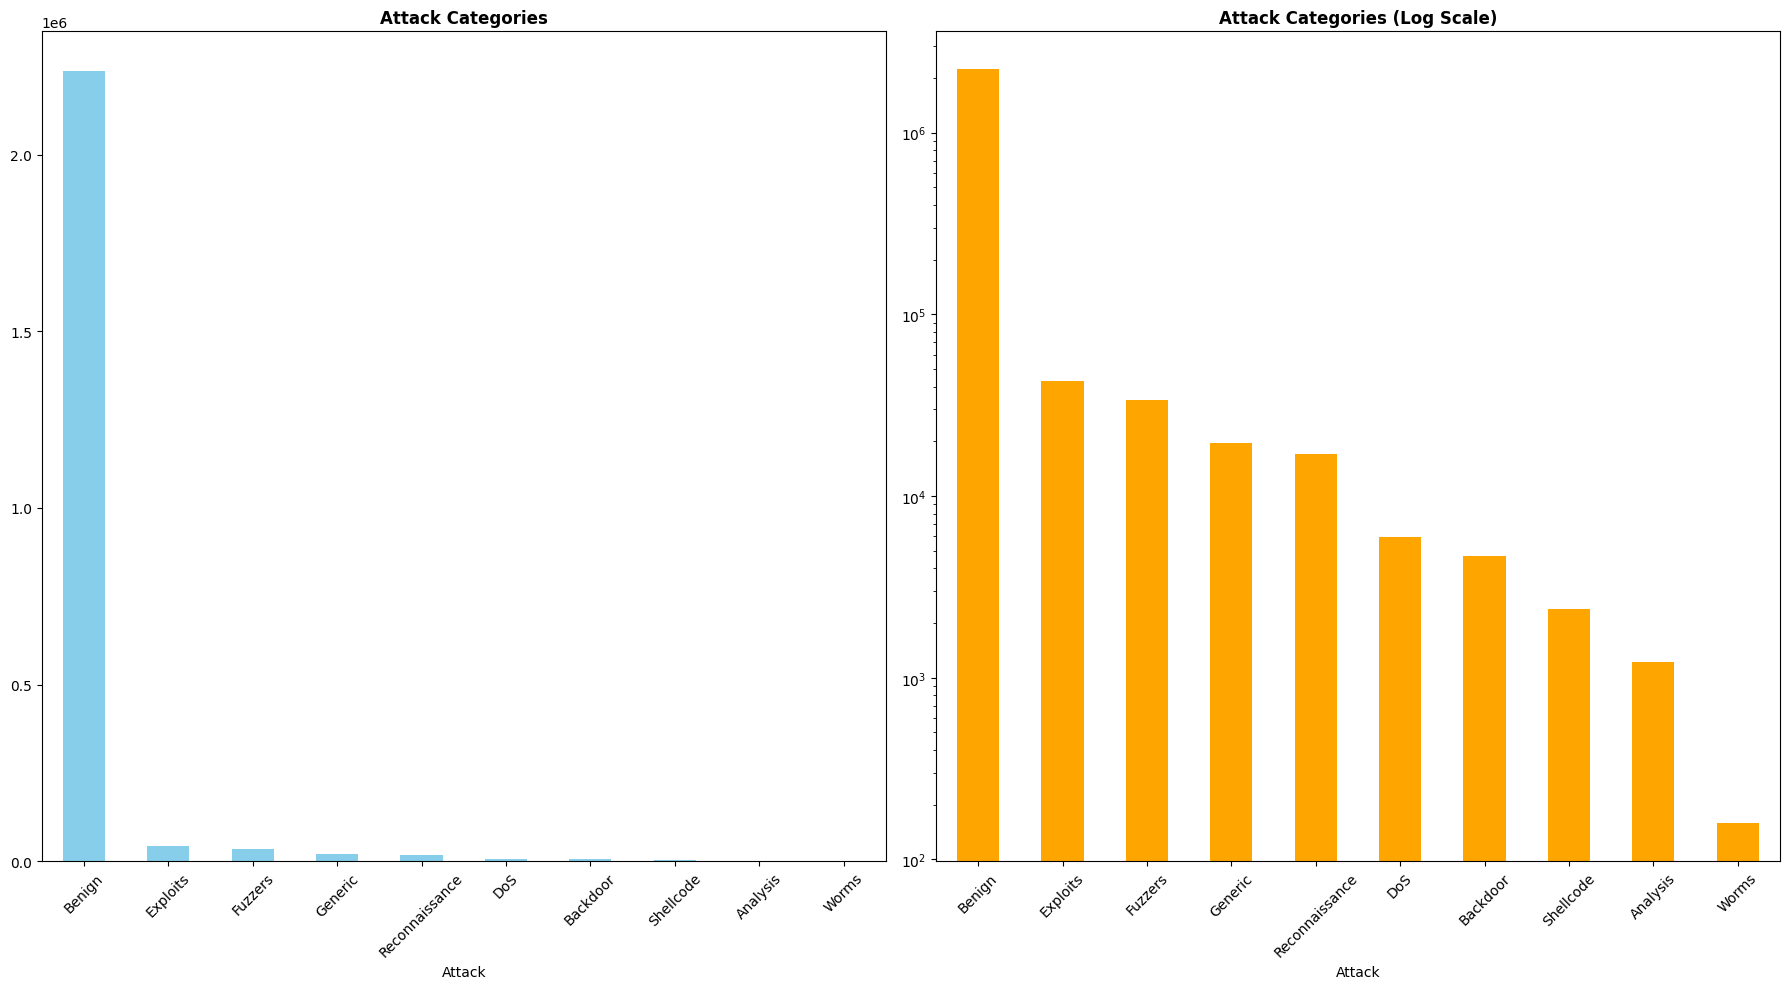


🎯 Attack Category Analysis:


,Count,Percentage
Attack,,
Benign,2237731,94.601687
Exploits,42748,1.807202
Fuzzers,33816,1.429596
Generic,19651,0.830760
Reconnaissance,17074,0.721816
DoS,5980,0.252809
Backdoor,4659,0.196963
Shellcode,2381,0.100658
Analysis,1226,0.051830



⚖️ Class Imbalance Ratio: 14162.85:1
⚠️ Strong class imbalance detected!


In [67]:
# Class distribution
if 'Attack' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    
    attack_counts = df['Attack'].value_counts()
    
    # Bar plot
    attack_counts.plot(kind='bar', ax=axes[0], color='skyblue')
    axes[0].set_title('Attack Categories', fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Log scale
    attack_counts.plot(kind='bar', ax=axes[1], logy=True, color='orange')
    axes[1].set_title('Attack Categories (Log Scale)', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Class distribution analysis
if 'Attack' in df.columns:
    print("\n🎯 Attack Category Analysis:")
    attack_dist = df['Attack'].value_counts()
    attack_pct = (attack_dist / len(df)) * 100
    
    attack_summary = pd.DataFrame({
        'Count': attack_dist,
        'Percentage': attack_pct
    })
    display(attack_summary)
    
    # Imbalance ratio
    imbalance_ratio = attack_dist.max() / attack_dist.min()
    print(f"\n⚖️ Class Imbalance Ratio: {imbalance_ratio:.2f}:1")
    
    if imbalance_ratio > 10:
        print("⚠️ Strong class imbalance detected!")
    else:
        print("✅ Acceptable class balance")

- **Starkes Klassenungleichgewicht:** Die Visualisierung und die prozentuale Verteilung zeigen ein extremes Ungleichgewicht zwischen den Klassen. Fast 95% des Traffics sind `Benign` (gutartig).
- **Seltene Angriffsklassen:** Einige Angriffstypen wie `Worms` oder `Analysis` sind extrem selten (unter 0,1%). Dies stellt eine große Herausforderung dar, da ein Modell dazu neigen könnte, diese Klassen zu ignorieren und trotzdem eine hohe Genauigkeit (Accuracy) zu erzielen.
- **Logarithmische Skala:** Die Darstellung im logarithmischen Maßstab macht die massiven Unterschiede in den Häufigkeiten besonders deutlich.
- **Konsequenz für das Training:** Dieses Ungleichgewicht muss im Preprocessing- und Trainingsprozess adressiert werden. Techniken wie Resampling (z.B. SMOTE für Oversampling seltener Klassen oder Undersampling der Mehrheitsklasse) oder die Verwendung von gewichteten Verlustfunktionen sind notwendig, um ein faires und effektives Modell zu trainieren.


# Verteilungsanalyse der Features
In diesem Hauptabschnitt untersuchen wir die Verteilungen der einzelnen Features. Wir unterteilen dies in drei Schritte:

1. Histogramme für numerische Features, um die Form der Verteilung zu sehen.
2. Häufigkeitszählungen für die wichtigsten kategorialen Features.
3. Boxplots für numerische Features, um gezielt nach Ausreißern zu suchen.


## Verteilung numerischer Features (Histogramme)

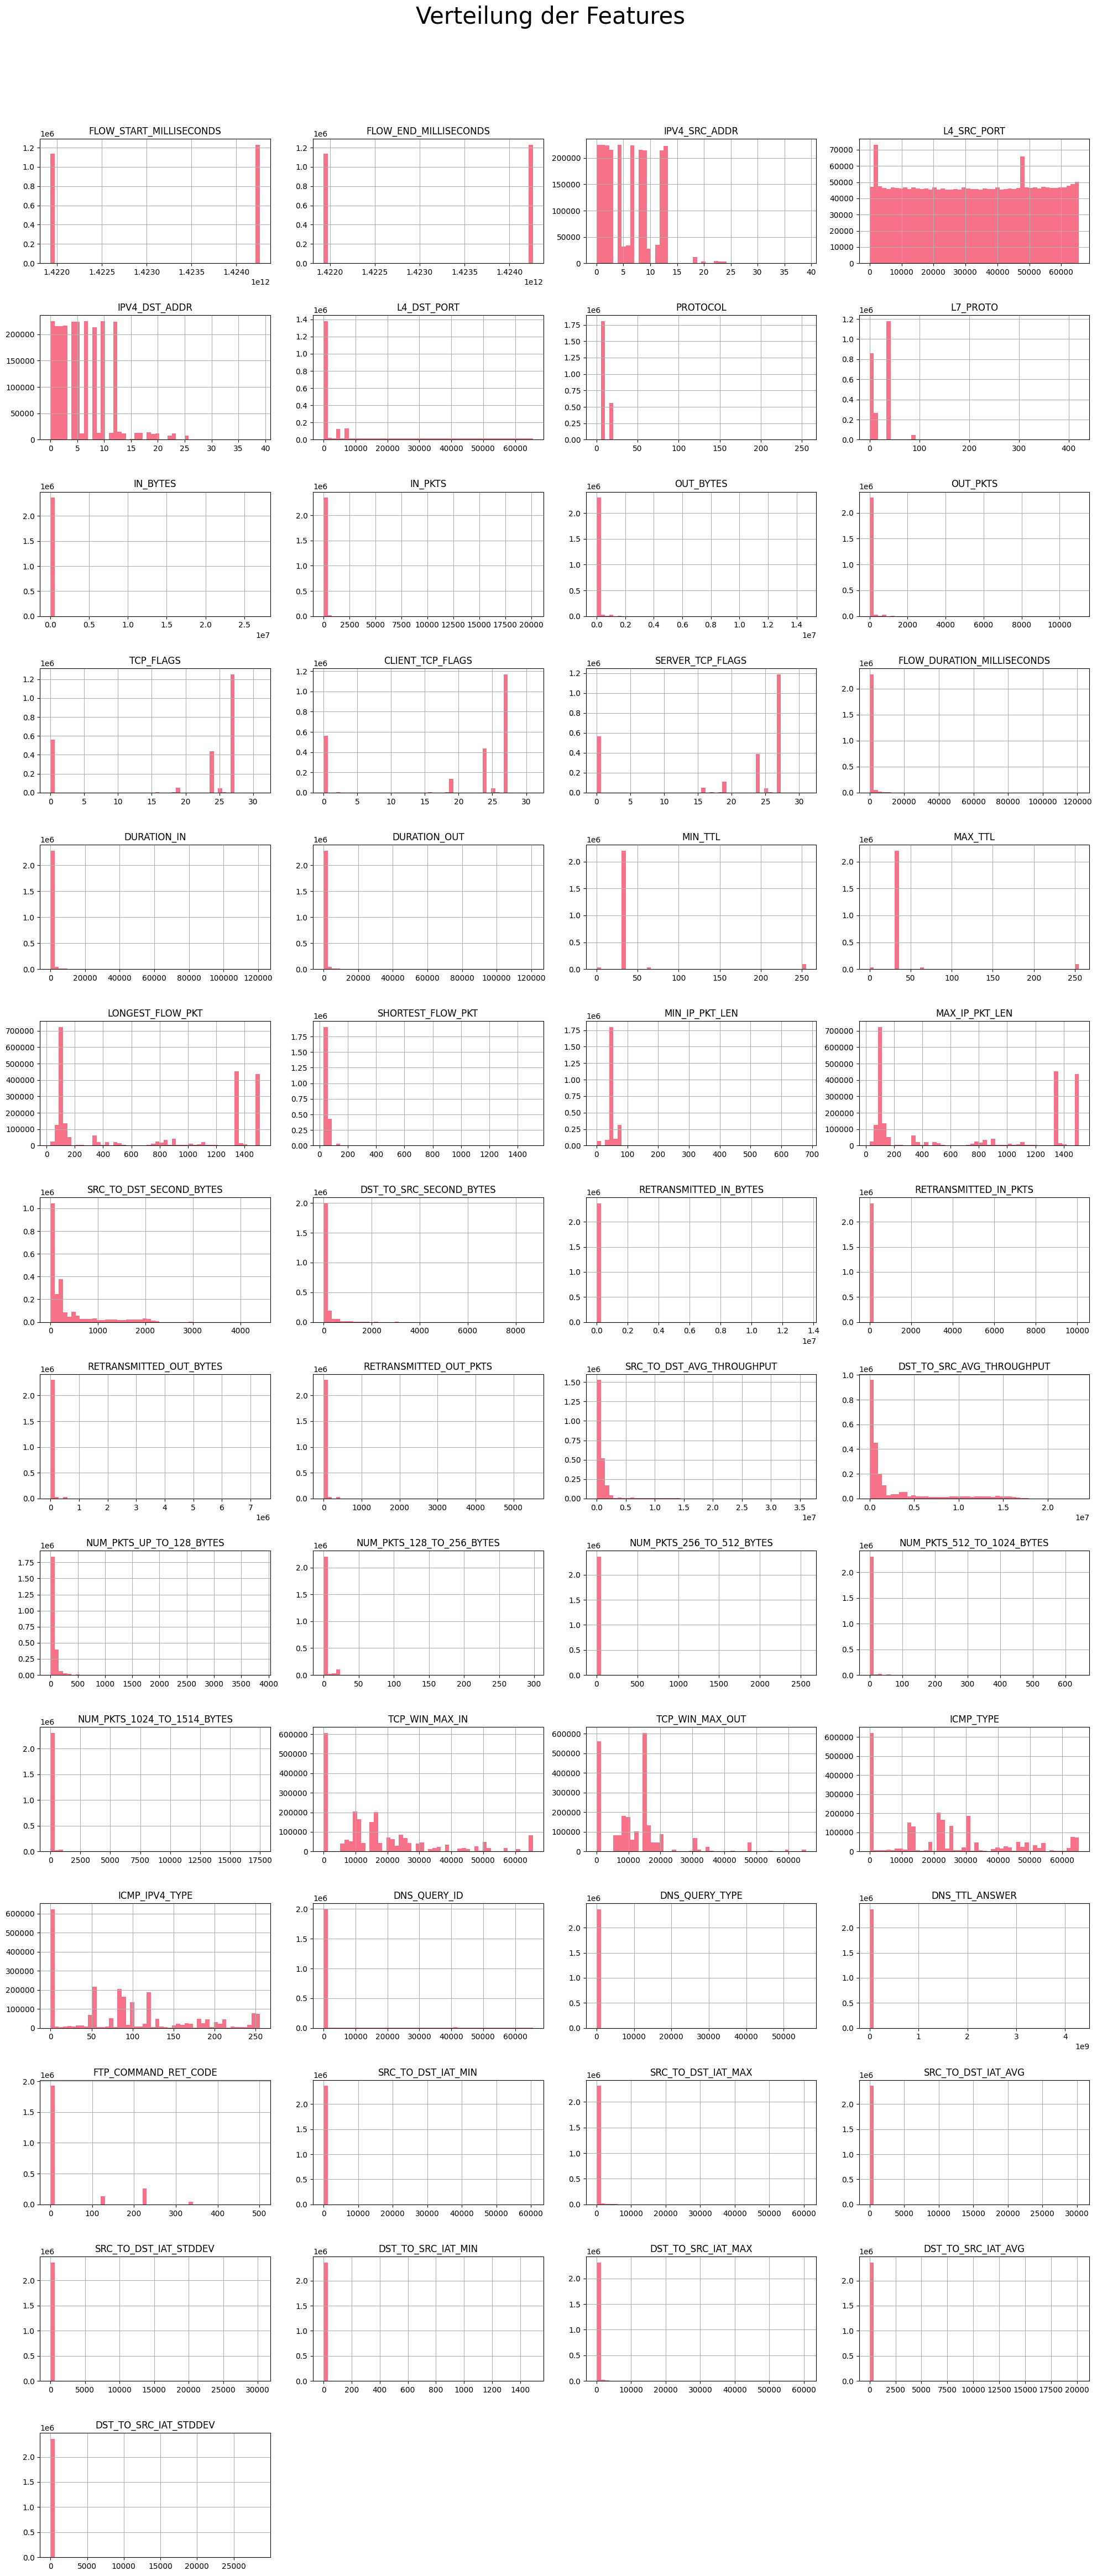

In [71]:
#print("Erstelle temporäre Kopie für Korrelationsanalyse...")
#df_for_corr = df.copy()

#print("Bereinige Kopie von NaN/inf und kodiere kategoriale Spalten...")
# Temporäre Bereinigung
#df_for_corr.replace([np.inf, -np.inf], np.nan, inplace=True)
#df_for_corr.fillna(0, inplace=True)

# Temporäre Kodierung
for col in df_for_corr.select_dtypes(include='object').columns:
    df_for_corr[col], _ = pd.factorize(df_for_corr[col])


num_features = len(df_for_corr[final_feature_columns].columns)
rows = (num_features // 4) + (1 if num_features % 4 > 0 else 0)

# 2. Histogramme mit neuem Layout und angepasster Figurengröße erstellen
df_for_corr[final_feature_columns].hist(bins=50, figsize=(20, rows * 3.5), layout=(rows, 4))
plt.suptitle('Verteilung der Features', size=30)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

- **Rechts-schiefe Verteilungen:** Die Histogramme zeigen deutlich, dass fast alle numerischen Features stark rechts-schief sind. Das bedeutet, die meisten Werte konzentrieren sich im niedrigen Bereich (nahe Null), während einige wenige, sehr hohe Werte (Ausreißer) eine lange "Spur" nach rechts ziehen.
- **Typisch für Netzwerkdaten:** Dieses Muster ist für Netzwerk-Metriken charakteristisch. Viele Verbindungen sind kurz und übertragen wenig Daten, während wenige Verbindungen (z.B. große Downloads, Streaming) für die extremen Werte verantwortlich sind.
- **Auswirkungen auf Modelle:** Modelle, die Normalverteilungen annehmen (wie lineare Modelle), könnten durch diese Schiefe negativ beeinflusst werden. Eine Log-Transformation könnte hier Abhilfe schaffen und die Verteilungen symmetrischer machen.

## Ausreißer-Analyse (Boxplots)
Nachdem die Histogramme uns erste Hinweise auf schiefe Verteilungen gegeben haben, verwenden wir nun Boxplots, um Ausreißer explizit zu visualisieren. Ein Ausreißer ist ein Datenpunkt, der signifikant von den anderen Beobachtungen abweicht.

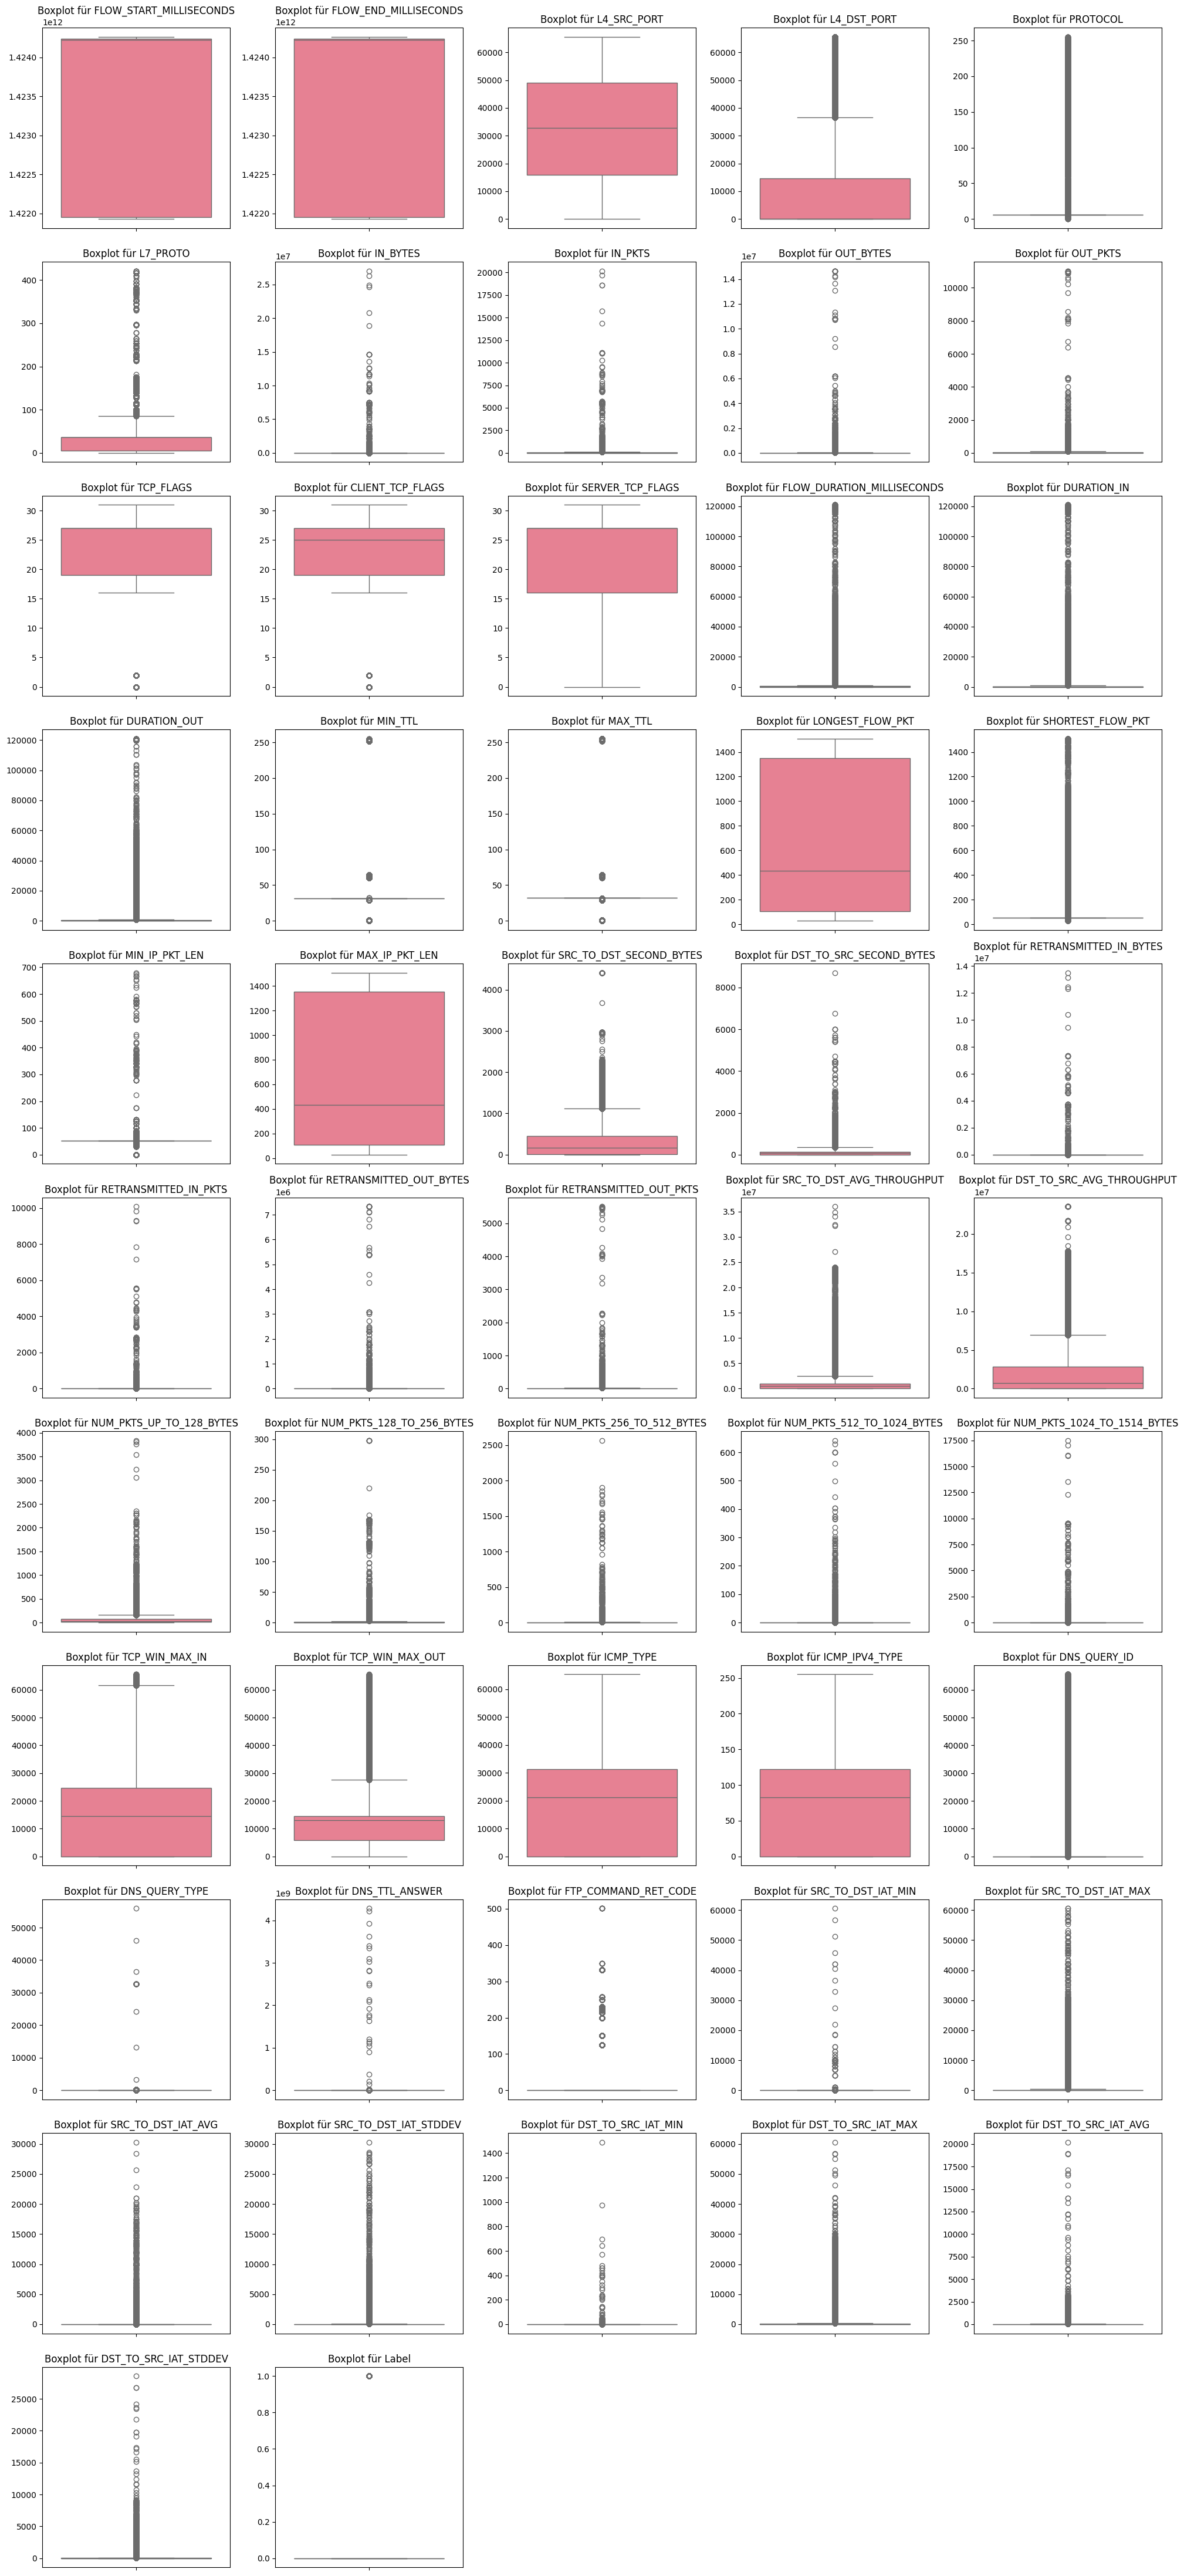

In [13]:
# Layout für die Boxplots festlegen (ähnlich wie bei den Histogrammen)
numeric_features = df.select_dtypes(include=np.number)
num_features = len(numeric_features.columns)
cols = 5
rows = (num_features // cols) + (1 if num_features % cols > 0 else 0)

# Erstelle eine Figure und eine Menge von Subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
# Umwandeln der 'axes'-Matrix in einen flachen Array für einfache Iteration
axes = axes.flatten()

# Erstelle für jedes numerische Feature einen Boxplot
for i, col in enumerate(numeric_features.columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot für {col}')
    axes[i].set_ylabel('') # Y-Achsenbeschriftung für Übersichtlichkeit entfernen

# Verstecke ungenutzte Subplots, falls die Anzahl nicht perfekt aufgeht
for i in range(num_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
print("\n🎯 Outlier Analysis:")
outlier_results = []

for col in final_feature_columns:
    if df[col].dtype in ['int64', 'float64']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_pct = (len(outliers) / len(df)) * 100
        
        outlier_results.append({
            'Feature': col,
            'Outlier_Count': len(outliers),
            'Outlier_Percentage': outlier_pct
        })

outlier_df = pd.DataFrame(outlier_results).sort_values('Outlier_Percentage', ascending=False)
display(outlier_df)


🎯 Outlier Analysis:


,Feature,Outlier_Count,Outlier_Percentage
20,MIN_IP_PKT_LEN,575104,24.312935
19,SHORTEST_FLOW_PKT,571445,24.158248
11,CLIENT_TCP_FLAGS,562382,23.775103
10,TCP_FLAGS,562339,23.773285
4,PROTOCOL,560154,23.680913
17,MAX_TTL,500712,21.167960
33,NUM_PKTS_512_TO_1024_BYTES,465297,19.670765
42,FTP_COMMAND_RET_CODE,440126,18.606643
49,DST_TO_SRC_IAT_AVG,393551,16.637651
39,DNS_QUERY_ID,380544,16.087771


- **Bestätigung der Ausreißer:** Die Boxplots bestätigen eindrücklich die Präsenz von massiven Ausreißern in fast allen numerischen Features. Die "Box" (die den Interquartilsabstand von 25% bis 75% darstellt) ist oft sehr klein und nahe Null, während unzählige Datenpunkte weit darüber liegen.
- **Interpretation der Ausreißer:** Diese Ausreißer sind nicht zwangsläufig Fehler. Sie repräsentieren reale, aber extreme Netzwerkaktivitäten wie sehr lange Datenflüsse (`FLOW_DURATION_MILLISECONDS`) oder Übertragungen großer Datenmengen (`IN_BYTES`, `OUT_BYTES`).
- **Robustheit von Modellen:** Die hohe Anzahl an Ausreißern unterstreicht die Notwendigkeit, robuste Machine-Learning-Modelle zu wählen. Baum-basierte Modelle wie Random Forest oder Gradient Boosting sind von Natur aus unempfindlicher gegenüber Ausreißern als distanzbasierte Modelle (z.B. SVM) oder lineare Modelle. Die Entscheidung, Ausreißer zu entfernen oder zu transformieren, muss sorgfältig abgewogen werden, da sie wertvolle Informationen über Angriffe enthalten könnten.

# Korrelationsanalyse
Wir untersuchen die linearen Beziehungen zwischen den Features und der Zielvariable. Eine Korrelationsmatrix hilft uns, zwei Dinge zu identifizieren:

1.  **Feature-Ziel-Korrelation:** Welche Features haben die stärkste positive oder negative Korrelation mit der `Label`-Spalte? Dies gibt erste Hinweise auf potenziell wichtige Merkmale.
2.  **Multikollinearität:** Welche Features sind untereinander stark korreliert? Hohe Korrelationen zwischen Features (z.B. > 0.9) können in manchen Modellen (insb. linearen Modellen) zu Problemen führen.

Wir verwenden die bereits bereinigte und kodierte Kopie `df_for_corr` für diese Analyse.

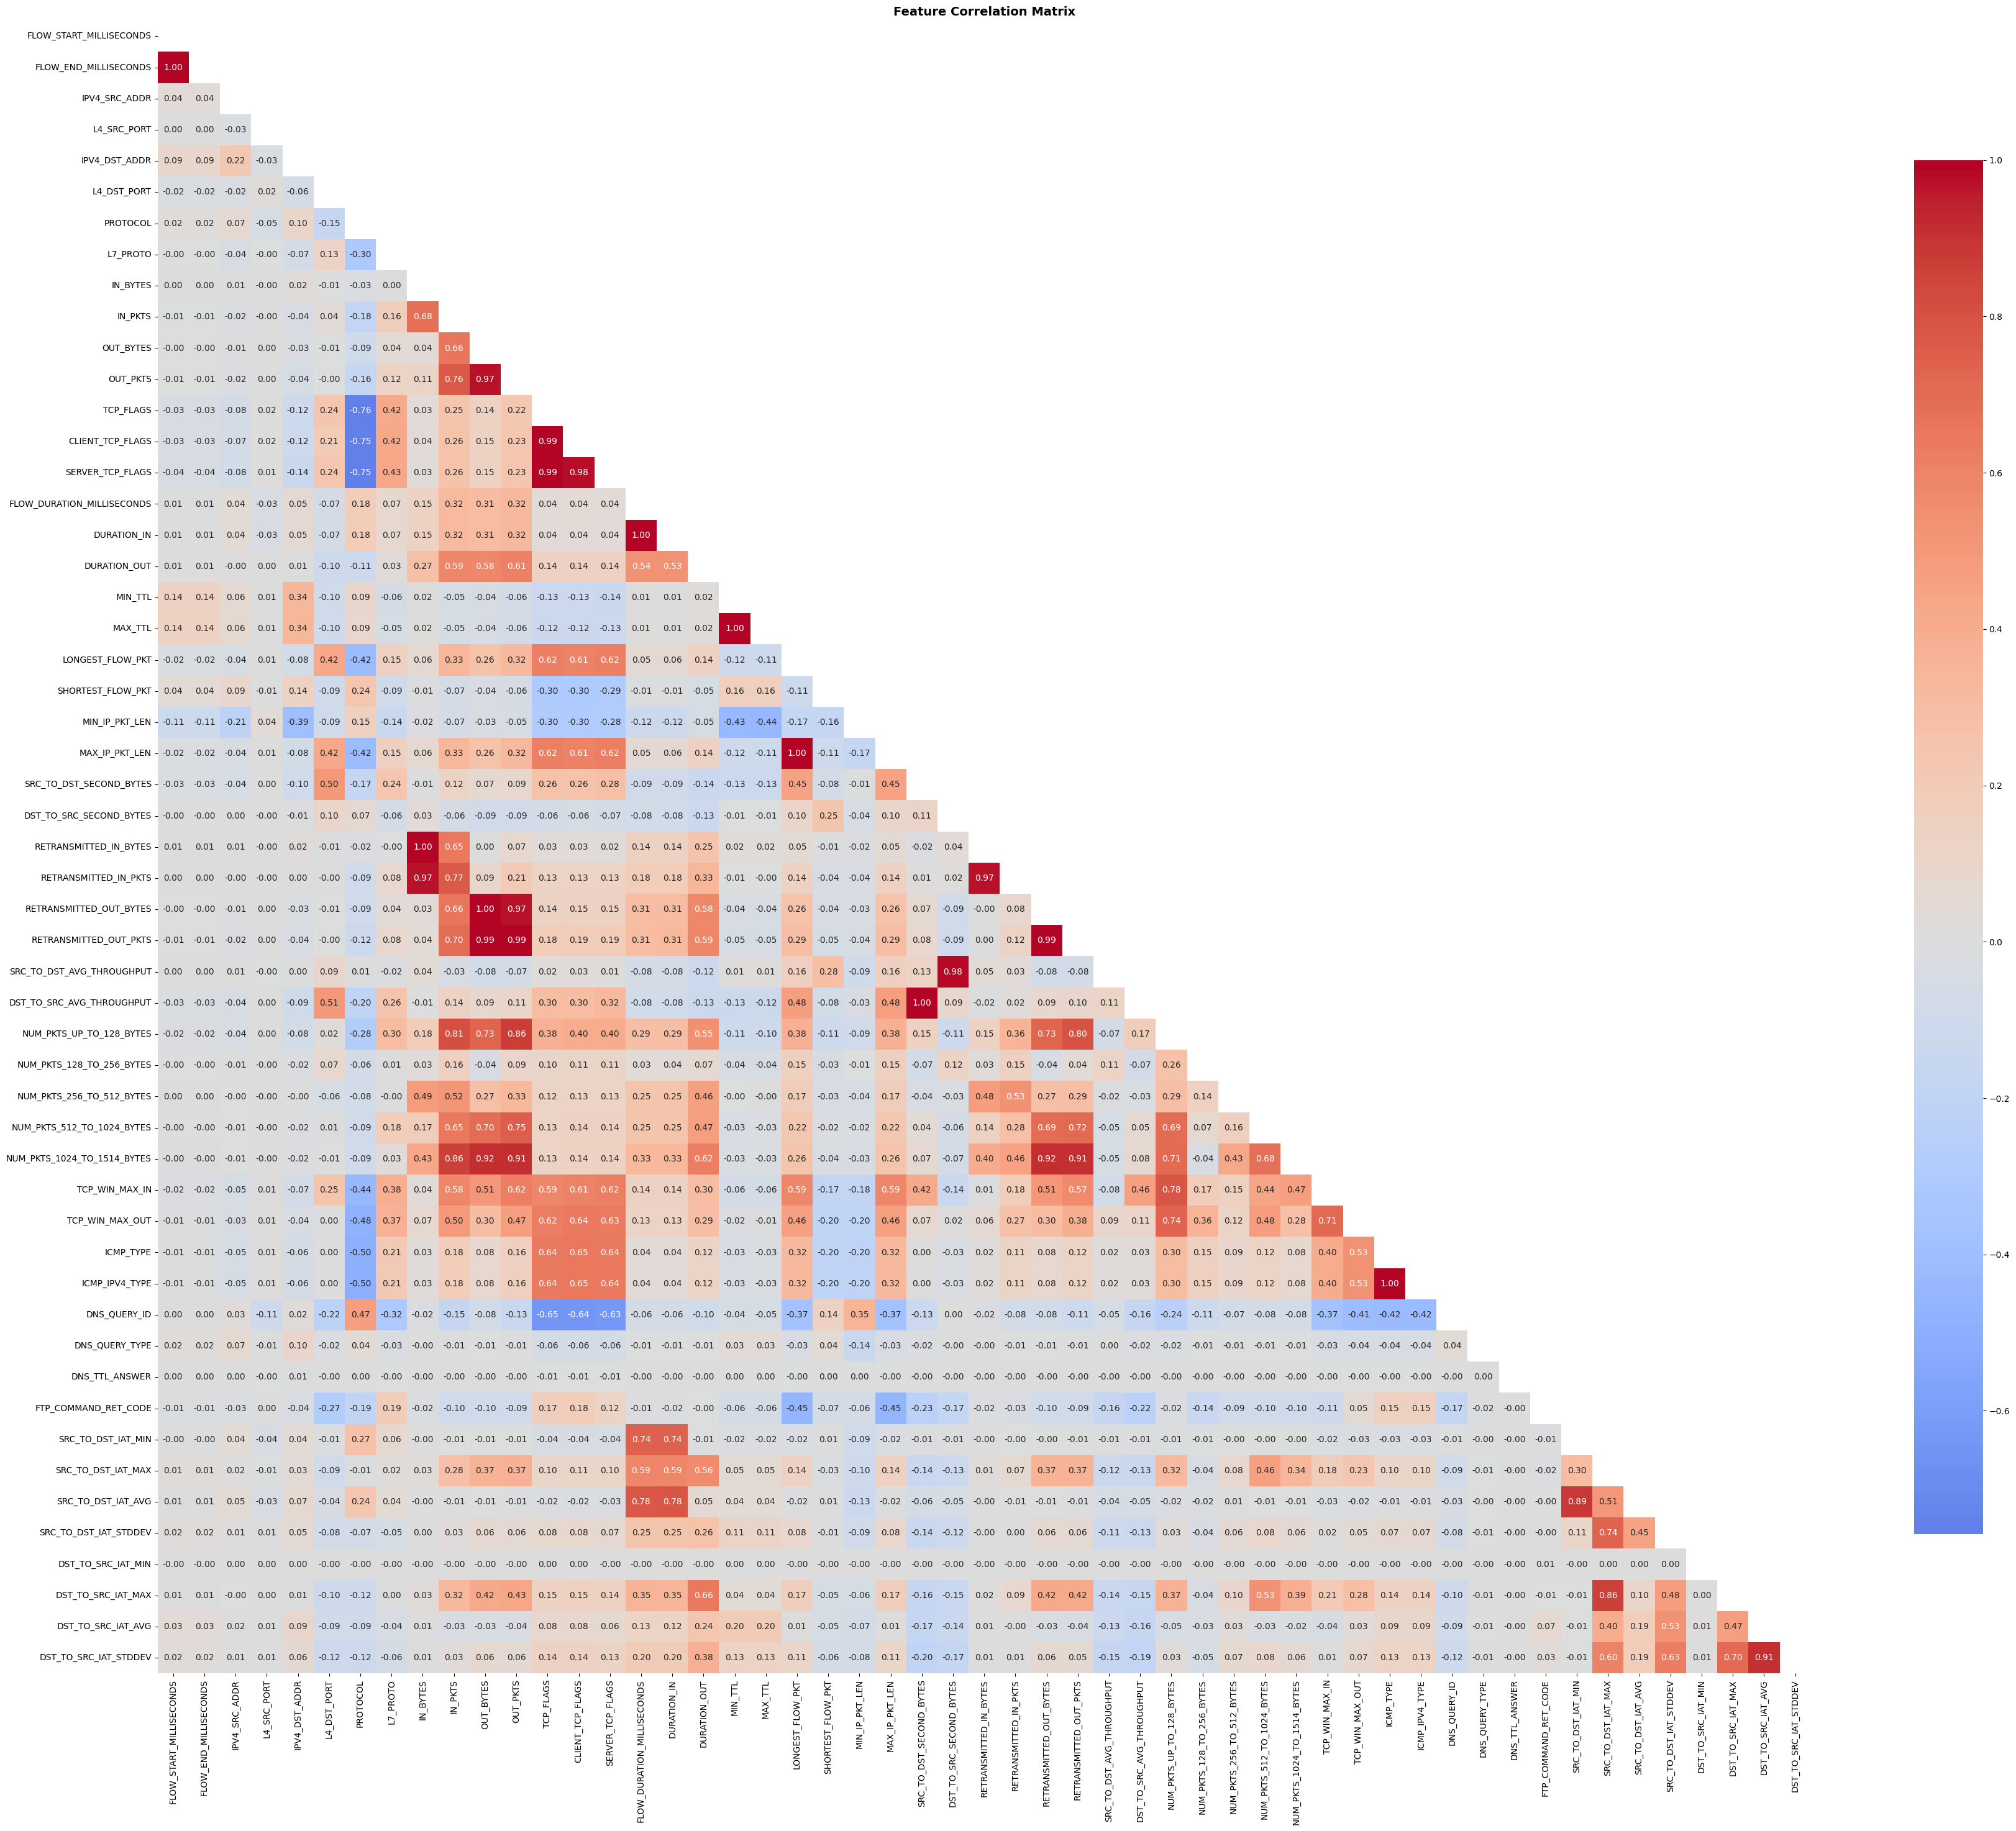

In [15]:
# Correlation heatmap
plt.figure(figsize=(36, 30))
corr_features = final_feature_columns
corr_subset = df_for_corr[corr_features].corr()

mask = np.triu(np.ones_like(corr_subset, dtype=bool))
sns.heatmap(corr_subset, mask=mask, annot=True, cmap='coolwarm', 
            center=0, square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Correlation analysis
print("\n🔗 High Correlations (|r| > 0.9):")
corr_matrix = df_for_corr[final_feature_columns].corr()
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.9:
            high_corr_pairs.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': corr_val
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    display(high_corr_df.sort_values('Correlation', key=abs, ascending=False))
else:
    print("✅ No highly correlated features found")


🔗 High Correlations (|r| > 0.9):


,Feature_1,Feature_2,Correlation
15,LONGEST_FLOW_PKT,MAX_IP_PKT_LEN,1.000000
0,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,1.000000
22,ICMP_TYPE,ICMP_IPV4_TYPE,1.000000
4,OUT_BYTES,RETRANSMITTED_OUT_BYTES,0.999981
14,MIN_TTL,MAX_TTL,0.999916
13,FLOW_DURATION_MILLISECONDS,DURATION_IN,0.999588
1,IN_BYTES,RETRANSMITTED_IN_BYTES,0.999223
16,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_AVG_THROUGHPUT,0.995732
5,OUT_BYTES,RETRANSMITTED_OUT_PKTS,0.991681
10,TCP_FLAGS,CLIENT_TCP_FLAGS,0.991300




- **Multikollinearität:** Die Heatmap deckt starke lineare Abhängigkeiten zwischen verschiedenen Features auf. Es gibt mehrere Cluster hochkorrelierter Features:
    - **Zeitstempel:** `FLOW_START_MILLISECONDS` und `FLOW_END_MILLISECONDS` sind fast perfekt korreliert, was logisch ist.
    - **Paketgrößen:** `MAX_IP_PKT_LEN` und `LONGEST_FLOW_PKT` sind identisch.
    - **Paketanzahlen und Bytes:** Features wie `IN_PKTS` und `NUM_PKTS_UP_TO_128_BYTES` oder `OUT_PKTS` und `OUT_BYTES` weisen ebenfalls hohe Korrelationen auf.
    - **TCP-Flags:** `CLIENT_TCP_FLAGS`, `SERVER_TCP_FLAGS` und `TCP_FLAGS` sind stark miteinander verbunden.

- **Konsequenzen:** Für baumbasierte Modelle wie Random Forest oder Gradient Boosting ist Multikollinearität weniger problematisch. Für lineare Modelle oder zur Reduzierung der Modellkomplexität könnte man jedoch in Erwägung ziehen, redundante Features (z.B. nur eines aus einem hochkorrelierten Paar) im Preprocessing zu entfernen.

## Analyse der Korrelation von Features mit Angriffskategorien


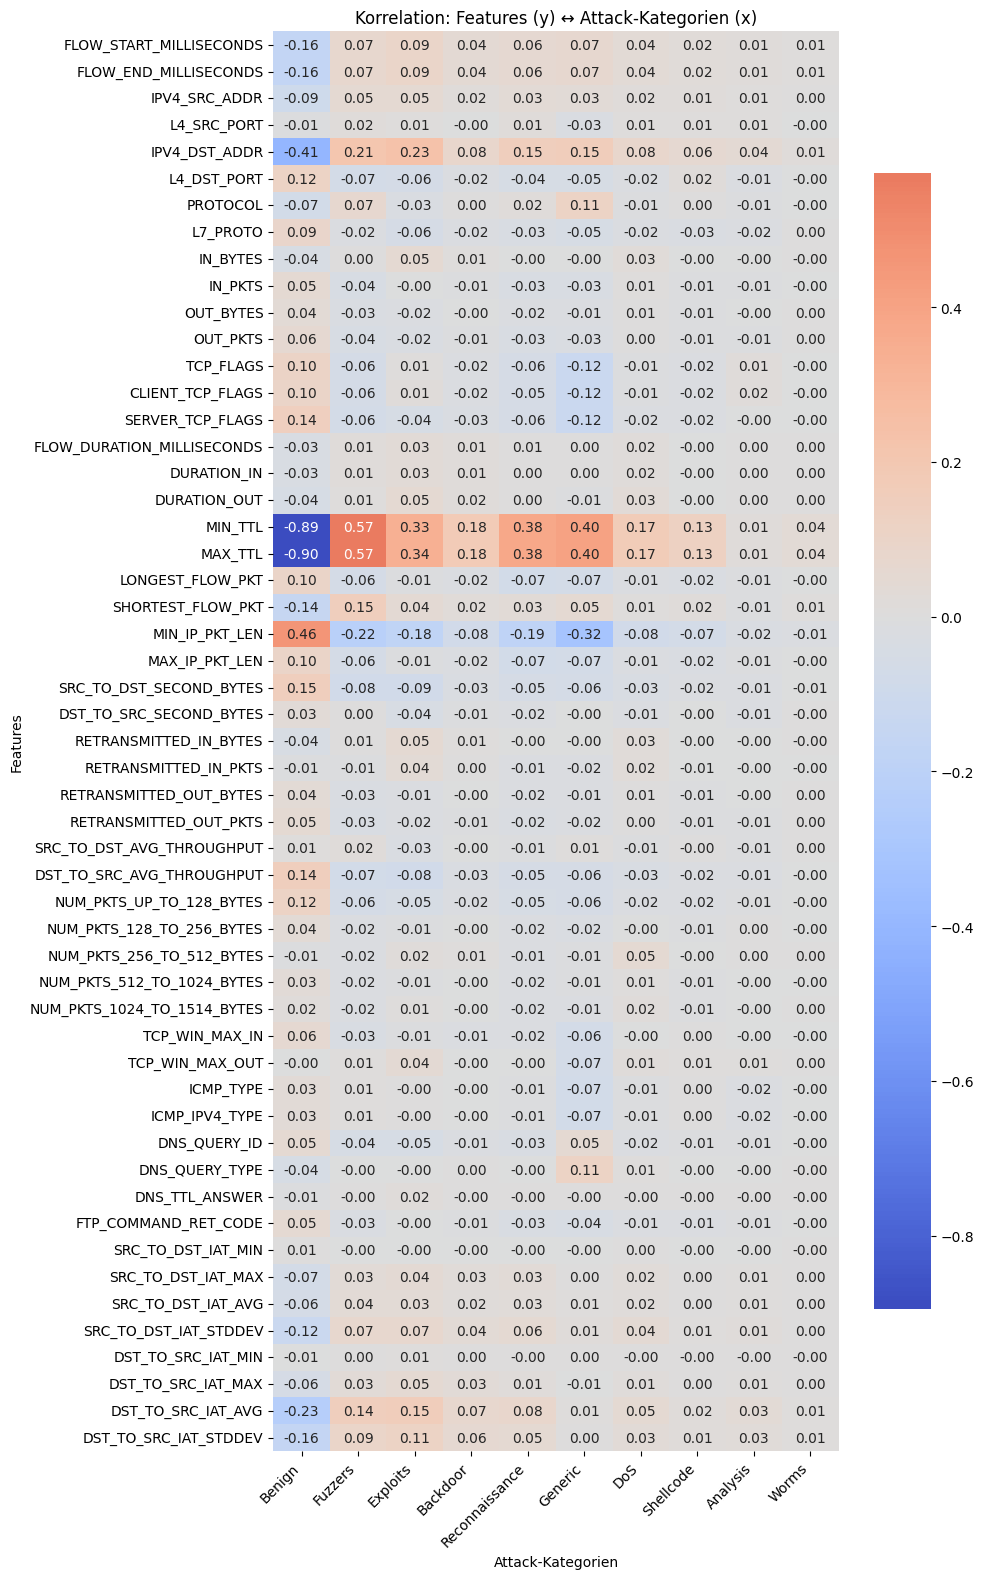

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

_ , attack_names = pd.factorize(df['Attack'])

unique_label_codes = sorted(df_for_corr['Attack'].unique())

X = df_for_corr[corr_features]  # Features
Y = df_for_corr['Attack']       # Labels (als numerische Codes)


corr_mat = pd.DataFrame({
    attack_names[label_code]: X.corrwith(Y == label_code) 
    for label_code in unique_label_codes
}, index=corr_features)


# Heatmap plotten
plt.figure(figsize=(max(8, len(unique_label_codes)*1), max(8, len(corr_features)*0.3)))
sns.heatmap(
    corr_mat,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    cbar_kws={"shrink": .8}
)
plt.title("Korrelation: Features (y) ↔ Attack-Kategorien (x)")
plt.xlabel("Attack-Kategorien")
plt.ylabel("Features")
plt.xticks(rotation=45, ha='right') # Rotiert die Labels für bessere Lesbarkeit
plt.tight_layout()
plt.show()

**Dominanz der TTL-Features:** `MIN_TTL` und `MAX_TTL` weisen die höchste diskriminative Kraft auf. Sie zeigen eine extrem starke negative Korrelation zu Benign (ca. -0.90) und eine signifikante positive Korrelation zu Fuzzers (0.57), Exploits und Generic. Dies deutet darauf hin, dass sich die Time-to-Live-Werte von Angriffsverkehr drastisch von normalem Verkehr unterscheiden.

**Paketgrößen als Indikator:** `MIN_IP_PKT_LEN` korreliert positiv mit gutartigem Verkehr (Benign: 0.46) und negativ mit Angriffen wie Generic (-0.32). Dies impliziert, dass Angriffe oft ungewöhnlich kleine oder fragmentierte Pakete verwenden, während legitimer Verkehr eine gewisse Mindestgröße beibehält.

**Adress- und Timing-Muster:** `IPV4_DST_ADDR` (-0.41 bei Benign) und `DST_TO_SRC_IAT_AVG` (Inter-Arrival Time) zeigen moderate Korrelationen. Dies signalisiert, dass sich die Verteilung der Zieladressen und die zeitlichen Abstände zwischen Paketen bei Angriffen (insbesondere Fuzzers/Exploits) signifikant von normalem Nutzerverhalten abheben.

**Erkennungsschwierigkeit bei "Stealth"-Angriffen:** Die Kategorien Analysis, Backdoor, Shellcode und Worms weisen durchgehend Korrelationswerte nahe 0 auf. Dies deutet auf zwei Möglichkeiten hin: Entweder sind diese Angriffe in diesem Datensatz stark unterrepräsentiert (Klassenungleichgewicht), oder ihre statistischen Merkmale sind im linearen Raum kaum vom Rauschen des Hintergrundverkehrs zu unterscheiden.

**TCP-Flags bei generischen Angriffen:** Features wie `TCP_FLAGS` oder `CLIENT/SERVER_TCP_FLAGS` zeigen eine leichte negative Korrelation zu Generic-Angriffen (-0.12). Dies lässt auf spezifische Anomalien im TCP-Handshake oder Flag-Setting (z. B. NULL- oder XMAS-Scans) schließen, die typisch für diese Kategorie sind.

**Feature-Redundanz:** Viele Features (z. B. `L4_SRC_PORT`, `OUT_BYTES`, diverse `TCP_WIN` Metriken) zeigen kaum Korrelation (< 0.05) über fast alle Klassen hinweg. Diese Features tragen isoliert betrachtet kaum zur Klassifizierung bei und könnten bei einer Feature-Selection Kandidaten für eine Eliminierung sein.

# Analyse der Feature Wichtigkeit für die Angriffsklassifikation



In [18]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

def get_feature_importance(X: pd.DataFrame, y: pd.Series) -> pd.Series:
    """
    Bestimmt die Feature Importance für ein Klassifikationsproblem mit einem RandomForestClassifier.

    Diese Funktion trainiert einen RandomForestClassifier auf den gegebenen Daten,
    extrahiert die Wichtigkeit der einzelnen Features und gibt sie in absteigender
    Reihenfolge zurück.

    Args:
        X (pd.DataFrame): DataFrame mit den Feature-Spalten.
        y (pd.Series): Series mit den Ziel-Labels für die Klassifikation.

    Returns:
        pd.Series: Eine Pandas-Serie mit den Feature-Namen als Index und ihren
                   Importance-Scores als Werte, sortiert von der höchsten zur
                   niedrigsten Wichtigkeit.
    """
    # --- Step 1: Initial Diagnostic ---
    print("--- Before conversion ---")
    # This set will show us all the unique data types present in the column names
    column_types_before = {type(c).__name__ for c in X.columns}
    print(f"Column name types found: {column_types_before}")
    if len(column_types_before) > 1:
        print("WARNING: Mixed types detected in column names before conversion.")

    # Fix für gemischte Spaltenname-Typen
    X = X.copy()
    X.columns = [str(col) for col in X.columns]  # Explizite Konvertierung

    # --- Step 3: Verification Diagnostic ---
    print("\n--- After conversion ---")
    column_types_after = {type(c).__name__ for c in X.columns}
    print(f"Column name types found: {column_types_after}")
    if len(column_types_after) > 1:
        print("ERROR: Mixed types STILL DETECTED after conversion. This is unexpected.")
    else:
        print("SUCCESS: Column names are now consistently typed.")
    
    print("-" * 25) # Separator for clarity
    # Initialisierung und Training des Modells
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X, y)

    # Extraktion der Feature Importances
    importances = model.feature_importances_

    # Erstellung einer Serie zur besseren Darstellung (Feature-Name -> Importance-Score)
    feature_importance_series = pd.Series(importances, index=X.columns)

    # Sortierung der Features nach Wichtigkeit
    sorted_feature_importance = feature_importance_series.sort_values(ascending=False)

    return sorted_feature_importance

# Verwendung:
feature_importances = get_feature_importance(df_for_corr[final_feature_columns], df_for_corr['Attack'])
print("\n📊 Feature Importances:")
print(feature_importances)

--- Before conversion ---
Column name types found: {'str'}

--- After conversion ---
Column name types found: {'str'}
SUCCESS: Column names are now consistently typed.
-------------------------

📊 Feature Importances:
MAX_TTL                        0.145905
MIN_TTL                        0.124076
SHORTEST_FLOW_PKT              0.088955
MIN_IP_PKT_LEN                 0.084187
IPV4_DST_ADDR                  0.055035
SRC_TO_DST_SECOND_BYTES        0.033686
L4_DST_PORT                    0.027996
MAX_IP_PKT_LEN                 0.027566
FLOW_START_MILLISECONDS        0.024858
FLOW_END_MILLISECONDS          0.024485
LONGEST_FLOW_PKT               0.024112
DST_TO_SRC_AVG_THROUGHPUT      0.022030
L4_SRC_PORT                    0.019042
SRC_TO_DST_AVG_THROUGHPUT      0.017320
L7_PROTO                       0.016131
IPV4_SRC_ADDR                  0.015135
IN_BYTES                       0.014603
DST_TO_SRC_SECOND_BYTES        0.013329
DNS_QUERY_TYPE                 0.013041
OUT_BYTES             

In [19]:
def get_per_label_feature_importance(X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    """
    Bestimmt die Feature Importance für jede einzelne Klasse (Label) in einem
    Multi-Class-Klassifikationsproblem.

    Verwendet einen One-vs-Rest-Ansatz, bei dem für jedes Label ein binärer
    Klassifikator trainiert wird, um dieses Label vom Rest zu unterscheiden.

    Args:
        X (pd.DataFrame): DataFrame mit den Feature-Spalten.
        y (pd.Series): Series mit den Multi-Class-Ziel-Labels.

    Returns:
        pd.DataFrame: Ein DataFrame, bei dem die Spalten die Labels und die
                      Zeilen die Features sind. Die Werte sind die Importance-Scores.
    """
    # Fix für gemischte Spaltenname-Typen
    X = X.copy()
    X.columns = [str(col) for col in X.columns]  # Explizite Konvertierung
    unique_labels = y.unique()
    importances_per_label = {}

    for label in unique_labels:
        # Erstelle ein binäres Ziel: aktuelles Label vs. alle anderen
        y_binary = (y == label)

        # Trainiere ein Modell für dieses binäre Problem
        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        model.fit(X, y_binary)

        # Speichere die Wichtigkeiten für dieses Label
        importances_per_label[label] = model.feature_importances_

    # Erstelle einen DataFrame aus den gesammelten Wichtigkeiten
    df_importances = pd.DataFrame(importances_per_label, index=X.columns)

    return df_importances
label_feature_importances = get_per_label_feature_importance(df_for_corr[final_feature_columns], df_for_corr['Attack'])


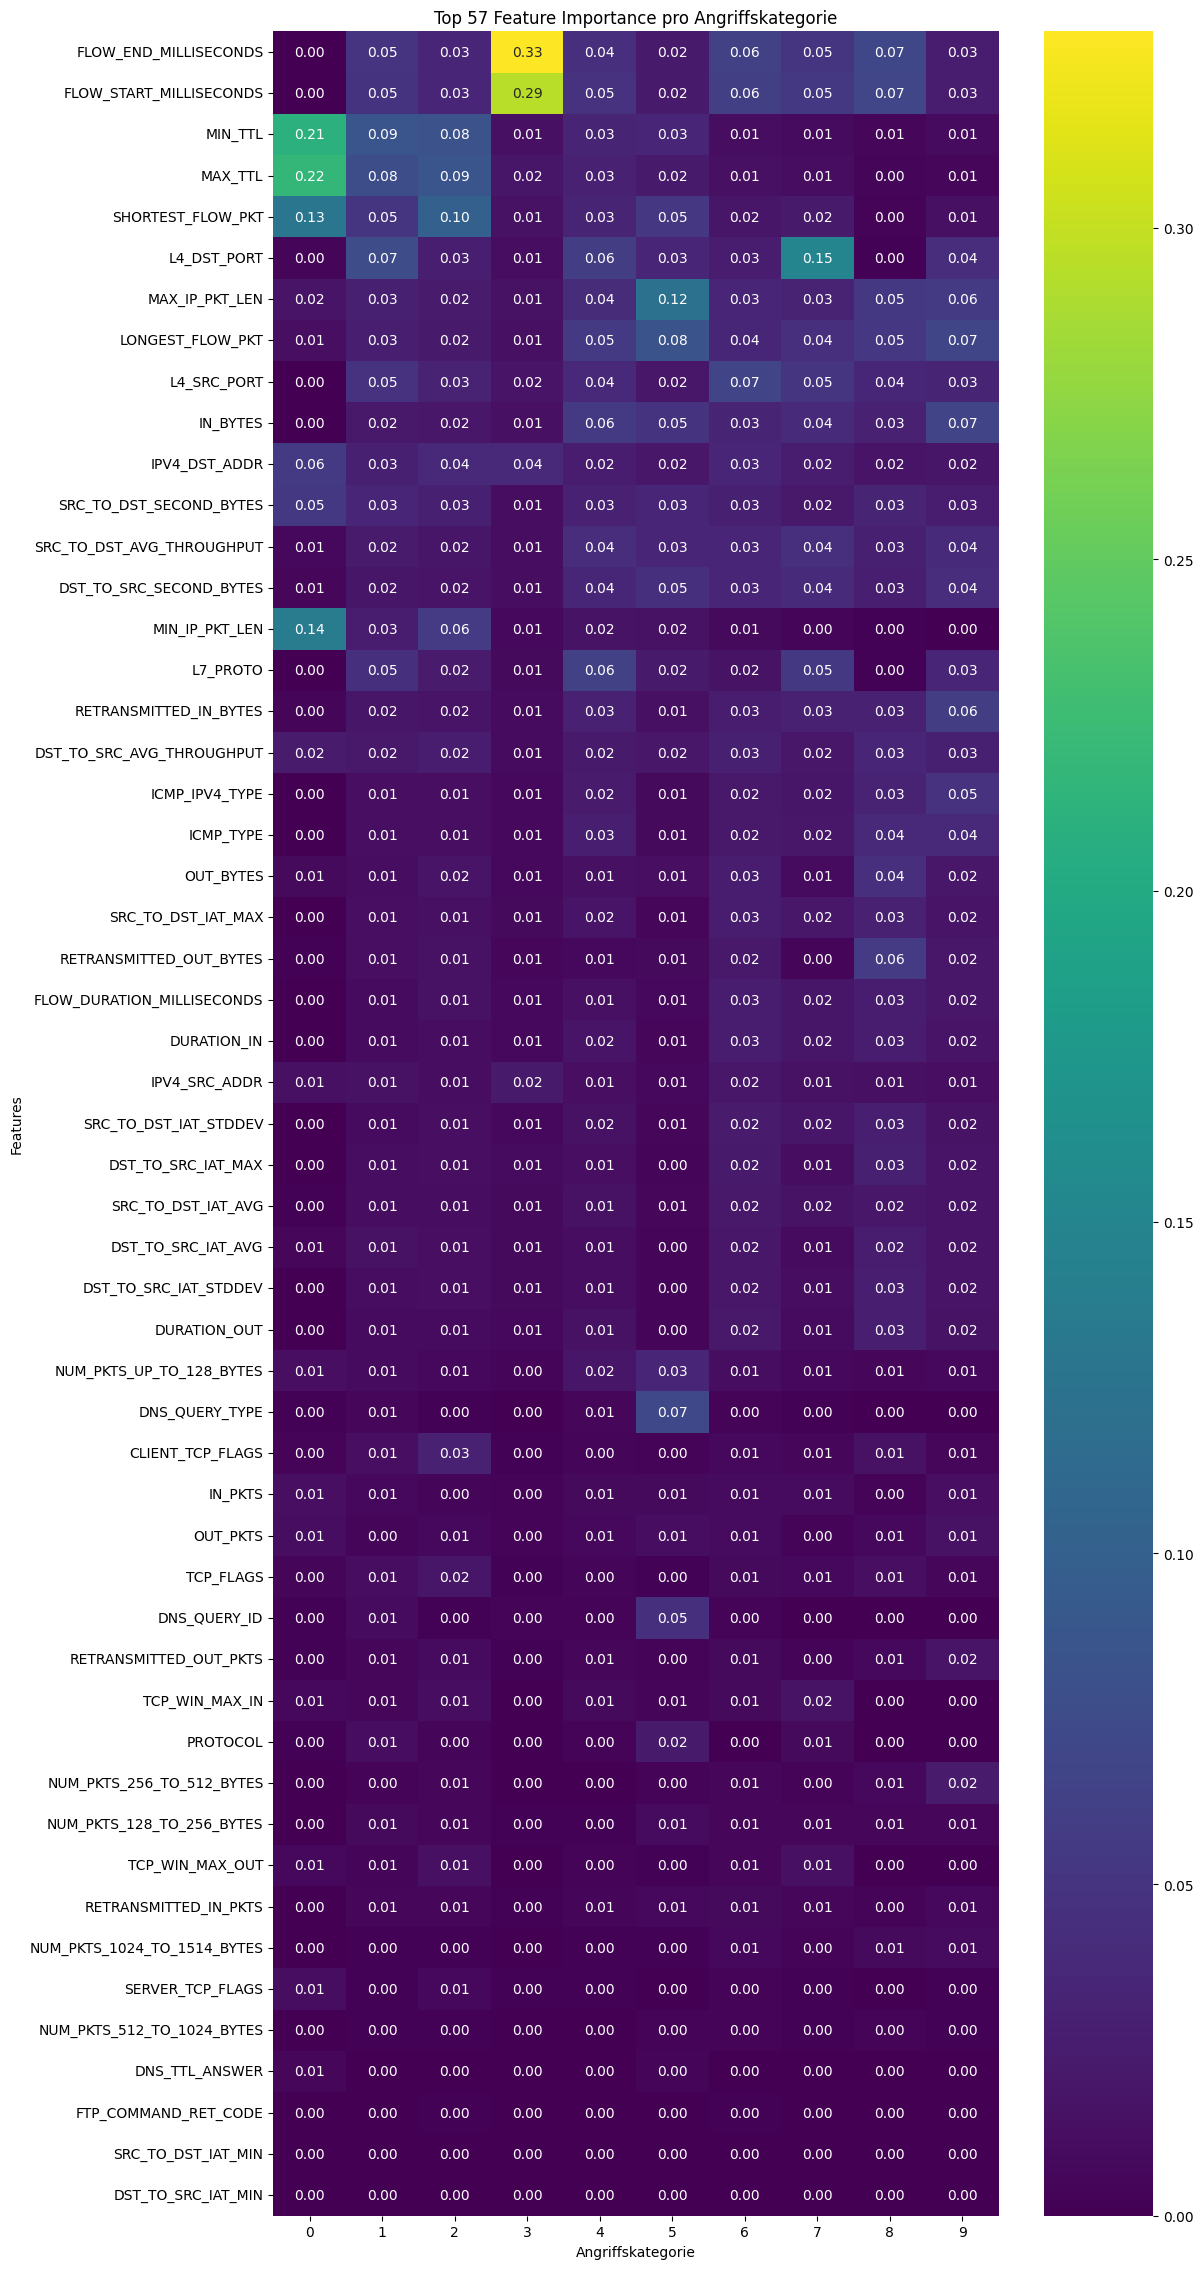

In [20]:
def plot_per_label_feature_importance(importance_df: pd.DataFrame, top_n: int = 20):
    """
    Erstellt eine Heatmap zur Visualisierung der Feature Importance pro Label.

    Args:
        importance_df (pd.DataFrame): DataFrame von get_per_label_feature_importance,
                                      mit Labels als Spalten und Features als Zeilen.
        top_n (int, optional): Die Anzahl der Top-Features, die angezeigt werden sollen.
                               Die Auswahl basiert auf der Summe der Wichtigkeit über alle Labels.
                               Defaults to 20.
    """
    # Finde die Top-N Features über alle Labels hinweg
    overall_importance = importance_df.sum(axis=1)
    top_features = overall_importance.nlargest(top_n).index
    
    # Filtere den DataFrame auf diese Top-Features
    df_to_plot = importance_df.loc[top_features]

    # Erstelle die Heatmap
    plt.figure(figsize=(12, max(6, top_n * 0.4))) # Dynamische Höhe
    sns.heatmap(df_to_plot, annot=True, cmap='viridis', fmt='.2f')
    
    plt.title(f'Top {top_n} Feature Importance pro Angriffskategorie')
    plt.xlabel('Angriffskategorie')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()
plot_per_label_feature_importance(label_feature_importances, top_n=57)

# Weitere Analysen des Datensatzes

## Analyse der Verteilung der Dauer eines NetFlows auf die Angriffsklassen

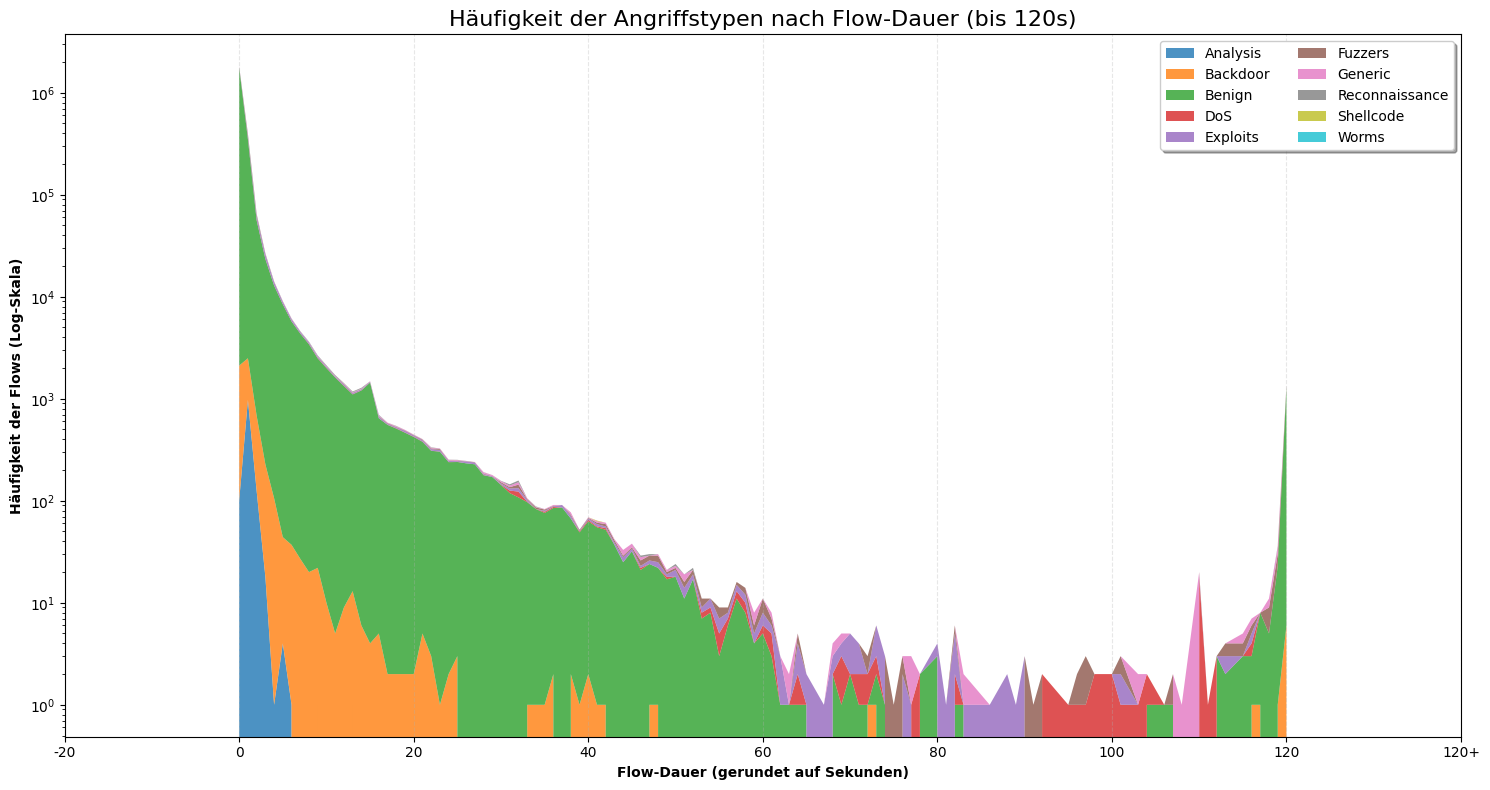

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def create_plot_by_rounded_seconds(df, max_seconds=120):
    """
    Erstellt einen gestapelten Plot, indem die Flow-Dauer auf ganze Sekunden gerundet
    und dann gruppiert wird. Längere Flows werden unter 'max_seconds+' zusammengefasst.
    """
    df_plot = df.copy()

    # 1. DEIN ANSATZ: Konvertiere Millisekunden zu Sekunden
    duration_sec = df_plot['FLOW_DURATION_MILLISECONDS'] / 1000
    
    # 2. VERBESSERUNG: Kappe lange Dauern für eine saubere Achse
    # Alle Flows, die länger als 'max_seconds' dauern, werden auf diesen Wert gesetzt,
    # um sie am Ende in einem Balken zu gruppieren.
    duration_sec.loc[duration_sec > max_seconds] = max_seconds
    
    # Runde auf ganze Sekunden
    rounded_sec = duration_sec.round().astype(int)
    
    # 3. GRUPPIEREN: Erstelle die Frequenztabelle basierend auf den gerundeten Sekunden
    attack_counts = pd.crosstab(rounded_sec, df_plot['Attack'])
    
    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(15, 8))
    
    x_values = attack_counts.index
    y_values = [attack_counts[col].values for col in attack_counts.columns]
    
    cmap = plt.get_cmap('tab10')
    colors = [cmap(i) for i in range(len(attack_counts.columns))]
    
    ax.stackplot(x_values, *y_values, 
                 labels=attack_counts.columns,
                 colors=colors,
                 alpha=0.8)

    # --- Achsen und Titel ---
    ax.set_xlabel('Flow-Dauer (gerundet auf Sekunden)', fontweight='bold')
    ax.set_ylabel('Häufigkeit der Flows (Log-Skala)', fontweight='bold')
    ax.set_yscale('log')
    ax.set_title(f'Häufigkeit der Angriffstypen nach Flow-Dauer (bis {max_seconds}s)', fontsize=16)

    # Passe die Beschriftung des letzten Ticks an, um "max_seconds+" anzuzeigen
    # Wir holen die aktuellen Ticks und formatieren sie neu
    ticks = ax.get_xticks()
    tick_labels = [f'{int(tick)}' for tick in ticks]
    if ticks.size > 0 and ticks[-1] >= max_seconds:
        tick_labels[-1] = f'{max_seconds}+'
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels)

    ax.legend(loc='upper right', ncol=2, frameon=True, shadow=True)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- Verwendung ---
# Analysiere die Dauern bis 30 Sekunden, alles darüber wird im "30+" Balken gesammelt.
create_plot_by_rounded_seconds(df, max_seconds=120)

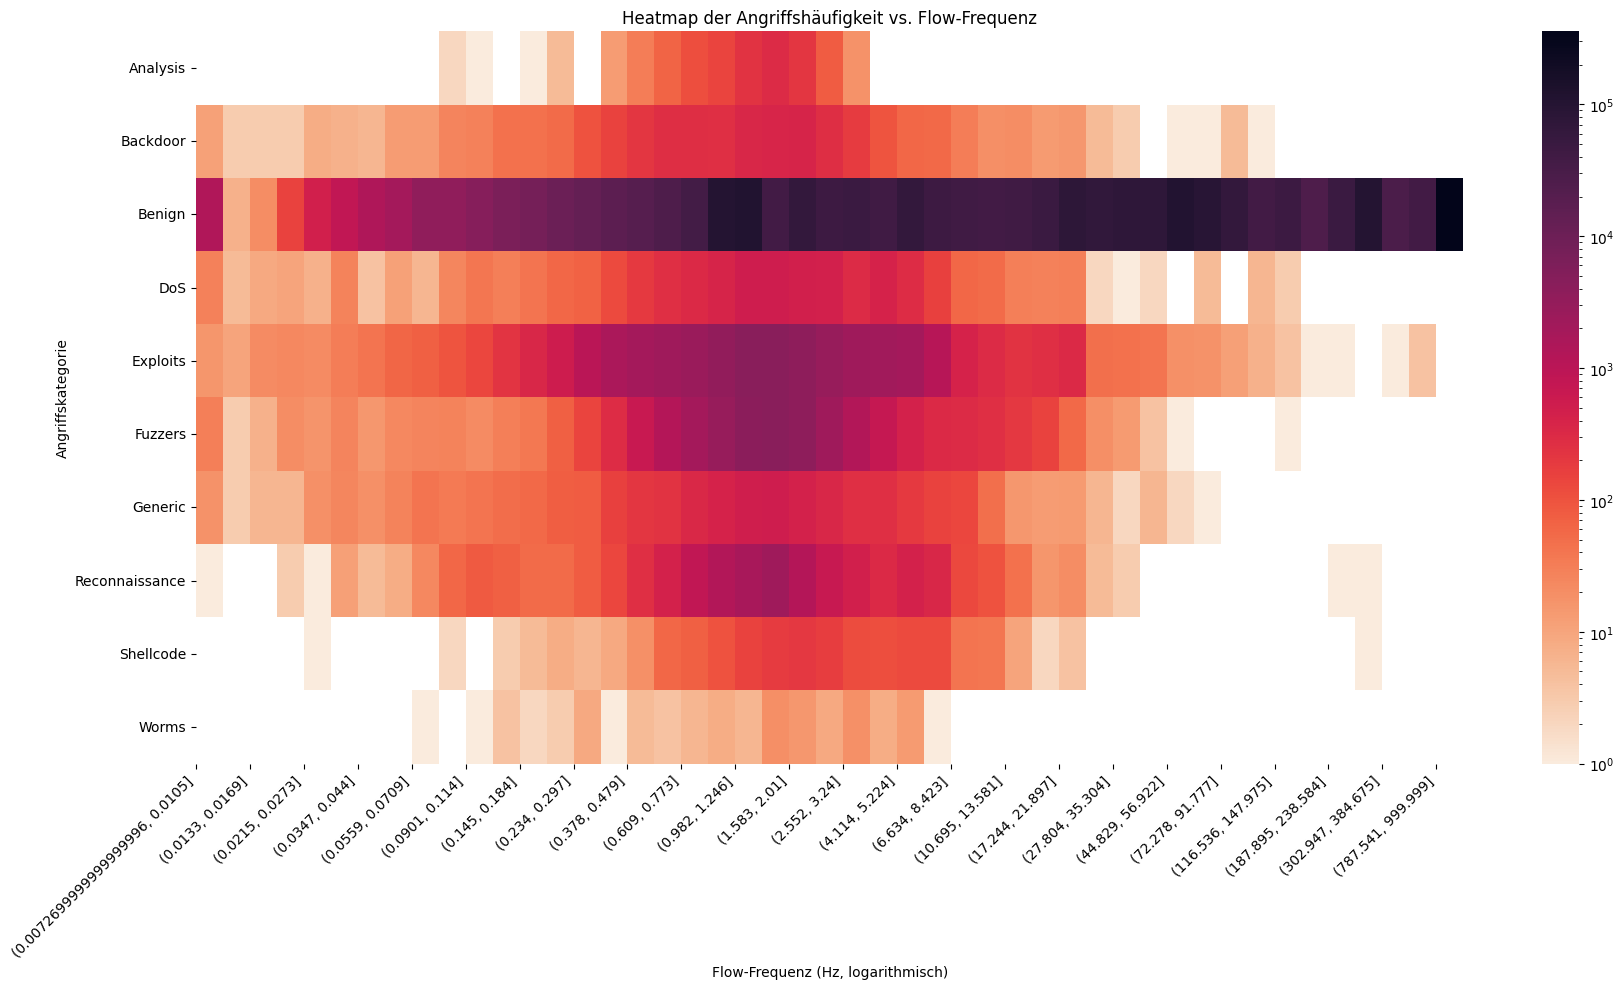

In [22]:
from matplotlib.colors import LogNorm

def plot_attack_frequency_heatmap(df: pd.DataFrame, num_bins: int = 50):
    """
    Erstellt eine Heatmap der Angriffshäufigkeiten in Abhängigkeit von der Flow-Frequenz in Hz.

    Args:
        df (pd.DataFrame): DataFrame, der die Spalten 'FLOW_DURATION_MILLISECONDS' und 'Attack' enthält.
        num_bins (int, optional): Die Anzahl der Frequenzbereiche, die auf der X-Achse gezeigt werden.
                                  Defaults to 50.
    """
    # Kopie erstellen, um Originaldaten nicht zu verändern
    df_copy = df.copy()

    # Berechne Frequenz in Hz. Füge Epsilon hinzu, um Division durch Null zu vermeiden.
    df_copy['Frequency_Hz'] = 1000 / (df_copy['FLOW_DURATION_MILLISECONDS'] + 1e-6)
    
    # Filtere extreme Ausreißer für eine bessere Visualisierung
    # (z.B. Frequenzen über 100 kHz, die oft aus minimalen Dauern resultieren)
    df_copy = df_copy[df_copy['Frequency_Hz'] < 100000]
    
    # Erstelle logarithmische Bins für die Frequenzachse
    min_val = df_copy['Frequency_Hz'].min()
    max_val = df_copy['Frequency_Hz'].max()
    if min_val <= 0:
        min_val = 1e-3 # Setze ein kleines Minimum, falls Frequenzen bei 0 starten

    bins = np.logspace(np.log10(min_val), np.log10(max_val), num=num_bins)
    df_copy['Hz_Bin'] = pd.cut(df_copy['Frequency_Hz'], bins=bins, include_lowest=True)

    # Erstelle die Kreuztabelle für die Heatmap
    attack_freq_crosstab = pd.crosstab(df_copy['Attack'], df_copy['Hz_Bin'])

    # Entferne Spalten ohne Angriffe, um die Ansicht zu säubern
    attack_freq_crosstab = attack_freq_crosstab.loc[:, (attack_freq_crosstab != 0).any(axis=0)]

    # Plot erstellen
    plt.figure(figsize=(18, 10))
    sns.heatmap(
        attack_freq_crosstab, 
        cmap='rocket_r', 
        norm=LogNorm(), # Logarithmische Skala für bessere Sichtbarkeit
        annot=False # Annotationen bei vielen Bins weglassen
    )

    plt.title('Heatmap der Angriffshäufigkeit vs. Flow-Frequenz')
    plt.xlabel('Flow-Frequenz (Hz, logarithmisch)')
    plt.ylabel('Angriffskategorie')
    
    # X-Achsen-Ticks für Lesbarkeit anpassen
    step = max(1, len(attack_freq_crosstab.columns) // 20) # Max 20 Ticks
    plt.xticks(np.arange(len(attack_freq_crosstab.columns))[::step],
               attack_freq_crosstab.columns[::step],
               rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

plot_attack_frequency_heatmap(df)

- **Power-Law-Verteilung:** Die überwältigende Mehrheit der Flows ist extrem kurz (< 1s), was typisch für verbindungslosen Verkehr oder kurze Requests ist.

- **Signaturen im Kurzbereich:** Angriffe wie Analysis und Backdoor konzentrieren sich auf 0–5s (Indiz für Scans und Probing ohne stabile Verbindung).

- **Artefakt durch Right-Censoring:** Der Peak bei 120s ist künstlich. Er repräsentiert keine natürliche Häufung, sondern aggregiert alle Flows, die durch das Aufzeichnungsfenster abgeschnitten wurden ("truncated data").

- **Informationsverlust am "Heavy Tail"**: Eine Unterscheidung zwischen "lang" (2 Min) und "sehr lang" (Stunden) ist unmöglich, was die Analyse persistenter Bedrohungen (z. B. C2-Tunnel) erschwert.

- **Statistische Lücke**: Der mittlere Zeitbereich (20–100s) ist fast leer; Flows sind tendenziell entweder sofort vorbei oder dauern bis zum Timeout an.

## Analyse, der Datenerhebung des Datensatzes
Können Zeitdaten für das Training von Modellen eingesetzt werden oder sind sie wertlos?

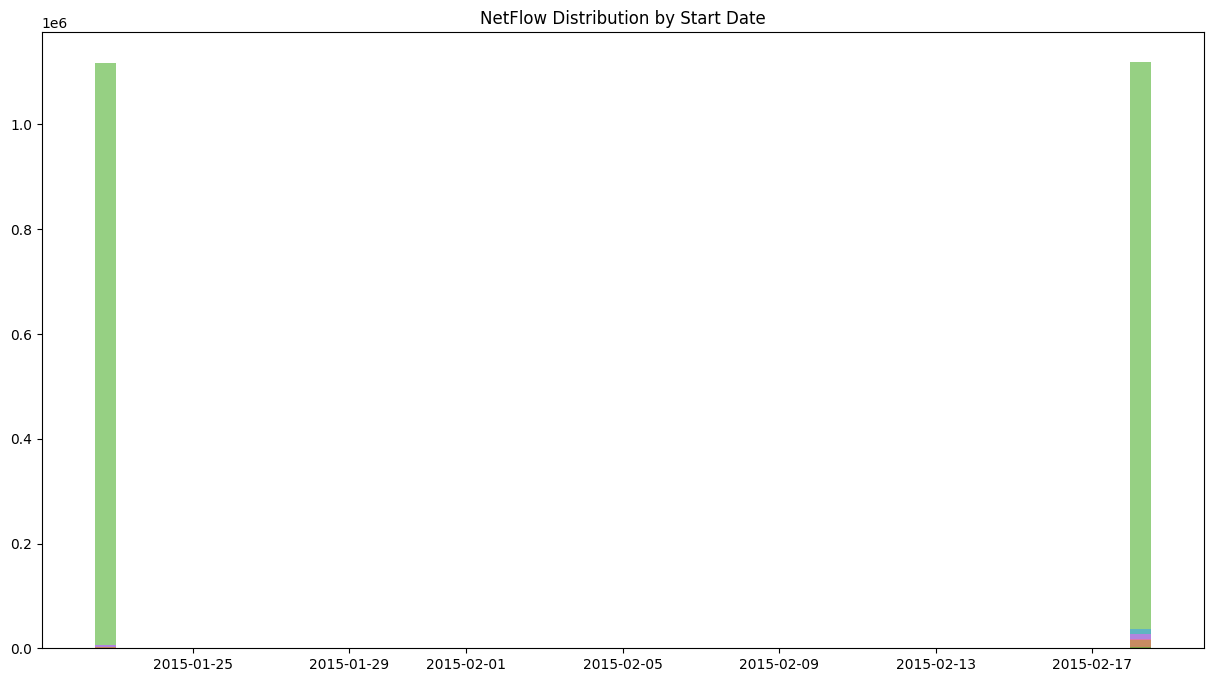

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Erstelle eine Figur und eine Achse für den Plot
fig, ax = plt.subplots(figsize=(15, 8))
plt.title("NetFlow Distribution by Start Date")

# 2. Iteriere durch jede Angriffskategorie
# df.groupby('Attack') gibt uns ein Tupel mit dem Namen der Gruppe und dem zugehörigen DataFrame
for attack_type, group_df in df.groupby('Attack'):
    
    # 3. Wandle die Millisekunden-Timestamps in Datums-Objekte um
    #    'unit="ms"' ist entscheidend, damit pandas die Zahl korrekt interpretiert
    dates = pd.to_datetime(group_df['FLOW_START_MILLISECONDS'], unit='ms')
    
    # 4. Zeichne das Histogramm für die aktuelle Gruppe auf der gemeinsamen Achse 'ax'
    #    Wir geben jeder Gruppe ein Label für die Legende
    ax.hist(dates, bins=50, alpha=0.6, label=attack_type)

# --- Formatierung der Achsen und Titel ---

# 5. Definiere das gewünschte Datumsformat für die x-Achse
date_format = mdates.DateFormatter('%Y-%m-%d') # Zeigt z.B. "2025-02-23"
ax.xaxis.set_major_formatter(date_format)



Die Datenerhebung für den `UNSW-NB15`-Datensatz fand an zwei Tagen statt: am 22. Januar und am 17. Februar 2015. Weitere Tage sind in den verfügbaren Quellen, Skripten und Publikationen nicht dokumentiert. Daher sind zeitliche Features für eine realistische Erkennung von IDS nicht aussagekräftig und sollten daher entfernt werden.


# 5. Zusammenfassung der EDA


Wichtigste Erkenntnisse:

1. Starkes Klassenungleichgewicht: Die Benign-Klasse ist überrepräsentiert.
2. Datenqualität: Es gibt inf- und NaN-Werte in einigen Spalten, die behandelt werden müssen.
3. Feature-Korrelation: Viele Features sind stark miteinander korreliert (z.B. Paketanzahl und Byte-Anzahl), was auf Redundanz hindeutet.
4. Datentypen: Es gibt einen Mix aus numerischen und kategorialen Daten, die für Machine-Learning-Modelle aufbereitet werden müssen.